# Imports

In [9]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image
from pathlib import Path
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
from tqdm import tqdm
import torch.optim as optim
from collections import defaultdict
import random
import copy
from torch import amp

# sklearn – needed for evaluation metrics
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_fscore_support,
    roc_curve,
    auc,
)
from sklearn.preprocessing import label_binarize

import json


In [10]:
if torch.cuda.is_available():
    print("Cuda ok")


Cuda ok


# Globals

In [11]:
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MAX_SAMPLES   = 15_000
TRAIN_SIZE    = 0.70   # 70 % train
VAL_SIZE      = 0.15   # 15 % validation
TEST_SIZE     = 0.15   # 15 % test
BATCH_SIZE    = 100

EMBEDDING_DIM         = 256
EMBEDDING_FOURIER_DIM = 64
EMBEDDING_RGB_DIM     = 64
LEARNING_RATE = 1e-4
EPOCHS        = 50

IMAGE_SIZE = (224, 224)
Image.MAX_IMAGE_PIXELS = None

LAMBDA_VALUES = [0.1, 0.3, 0.5, 0.7, 0.9]

CHECKPOINT_DIR = Path("checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)

AI_LABELS     = ["real", "ai"]
DOMAIN_LABELS = ["original", "redigital", "transfer"]


# Utils

## Early Stopping

In [12]:
class EarlyStopping:
    def __init__(self, patience=5, delta=0, path='best_model.pth'):
        """
        Args:
            patience (int): Quante epoche aspettare dopo l'ultimo miglioramento prima di fermarsi.
            delta (float): Cambiamento minimo nella loss per essere considerato un vero miglioramento.
            path (str): Percorso dove salvare il modello migliore.
        """
        self.patience = patience
        self.delta = delta
        self.path = path
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        # Se è la prima epoca, inizializza la best_loss
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)

        # Se la loss attuale non è scesa abbastanza rispetto alla migliore
        elif val_loss > self.best_loss - self.delta:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True

        # Se la loss è migliorata (è scesa)
        else:
            print(f"Validation loss diminuita ({self.best_loss:.4f} --> {val_loss:.4f}). Salvo il modello!")
            self.best_loss = val_loss
            self.save_checkpoint(model)
            self.counter = 0 # Resetta il contatore

    def save_checkpoint(self, model):
        """Salva i pesi del modello quando la validation loss migliora."""
        torch.save(model.state_dict(), self.path)


## Useful Functions

In [13]:
def model_info(model):
    total_params     = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    size_in_mb = total_params * 4 / (1024 ** 2)
    print(f"Parametri Totali:       {total_params:,}")
    print(f"Parametri Addestrabili: {trainable_params:,}")
    print(f"Dimensione (float32):   {size_in_mb:.2f} MB")
    return total_params, trainable_params, size_in_mb


def train_multitask_model(model, train_loader, val_loader, epochs=EPOCHS,
                          learning_rate=LEARNING_RATE, device=None,
                          weight_task=0.5, checkpoint_path='checkpoint_best_model.pth',
                          patience=5, verbose=True):
    """Train the multi-task model for a SINGLE, FIXED value of weight_task
    (lambda) for its entire schedule, end to end, and return a history dict.

    weight_task (lambda) is fixed for the whole call: it is NOT changed
    batch-by-batch. To study the lambda trade-off, this function is called
    once per lambda value, each time starting from a freshly-initialized
    model (see `run_lambda_ablation_study` below).
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = model.to(device)
    early_stopping = EarlyStopping(patience=patience, path=checkpoint_path)

    criterion_ai     = nn.CrossEntropyLoss()
    criterion_domain = nn.CrossEntropyLoss()
    optimizer        = optim.AdamW(model.parameters(), lr=learning_rate)

    history = {
        'train_loss': [], 'val_loss': [],
        'val_acc_ai': [], 'val_acc_domain': [],
    }

    scaler = amp.GradScaler("cuda")
    for epoch in range(epochs):
        # ── TRAIN ──────────────────────────────────────────────────────────
        model.train()
        running_train_loss = 0.0
        train_loop = tqdm(train_loader, desc=f"[λ={weight_task}] Epoch [{epoch+1}/{epochs}] - Train",
                           disable=not verbose)

        for images, labels in train_loop:
            images       = images.to(device)
            label_ai     = labels['label_ai'].to(device)
            label_domain = labels['label_domain'].to(device)

            optimizer.zero_grad()

            with amp.autocast("cuda"):
                logits_binary, logits_transform = model(images)

                loss_ai     = criterion_ai(logits_binary, label_ai)
                loss_domain = criterion_domain(logits_transform, label_domain)
                # Fixed lambda for the whole training run (see docstring above)
                total_loss  = weight_task * loss_ai + (1 - weight_task) * loss_domain

            scaler.scale(total_loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_train_loss += total_loss.item()
            if verbose:
                train_loop.set_postfix(loss=total_loss.item())

        avg_train_loss = running_train_loss / len(train_loader)

        # ── VALIDATION ─────────────────────────────────────────────────────
        model.eval()
        running_val_loss = 0.0
        correct_ai = correct_domain = total_samples = 0

        with torch.no_grad():
            val_loop = tqdm(val_loader, desc=f"[λ={weight_task}] Epoch [{epoch+1}/{epochs}] - Val",
                             leave=False, disable=not verbose)
            for images, labels in val_loop:
                images       = images.to(device)
                label_ai     = labels['label_ai'].to(device)
                label_domain = labels['label_domain'].to(device)

                with amp.autocast("cuda"):
                    logits_binary, logits_transform = model(images)
                    loss_ai     = criterion_ai(logits_binary, label_ai)
                    loss_domain = criterion_domain(logits_transform, label_domain)
                    total_loss  = weight_task * loss_ai + (1 - weight_task) * loss_domain

                running_val_loss += total_loss.item()

                _, preds_ai     = torch.max(logits_binary,    dim=1)
                _, preds_domain = torch.max(logits_transform, dim=1)

                total_samples  += images.size(0)
                correct_ai     += (preds_ai     == label_ai).sum().item()
                correct_domain += (preds_domain == label_domain).sum().item()

        avg_val_loss  = running_val_loss / len(val_loader)
        acc_ai        = correct_ai     / total_samples
        acc_domain    = correct_domain / total_samples

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_acc_ai'].append(acc_ai)
        history['val_acc_domain'].append(acc_domain)

        if verbose:
            print(f"--- [λ={weight_task}] Epoch {epoch+1} ---")
            print(f"Training Loss:   {avg_train_loss:.4f}")
            print(f"Validation Loss: {avg_val_loss:.4f}")
            print(f"Val Accuracy AI: {acc_ai*100:.2f}% | Val Accuracy Domain: {acc_domain*100:.2f}%\n")

        early_stopping(avg_val_loss, model)
        if early_stopping.early_stop:
            print(f"[λ={weight_task}] Early stopping triggered...")
            break

    print(f"[λ={weight_task}] Training Completed")
    return history


def collect_predictions(model, loader, device=DEVICE):
    """Return arrays of true labels, predicted labels and softmax probabilities."""
    model.eval()
    model.to(device)

    all_true_ai,     all_pred_ai,     all_prob_ai     = [], [], []
    all_true_domain, all_pred_domain, all_prob_domain = [], [], []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Inference'):
            images       = images.to(device)
            label_ai     = labels['label_ai'].to(device)
            label_domain = labels['label_domain'].to(device)

            logits_binary, logits_transform = model(images)

            prob_ai     = F.softmax(logits_binary,    dim=1)
            prob_domain = F.softmax(logits_transform, dim=1)

            _, preds_ai     = torch.max(logits_binary,    dim=1)
            _, preds_domain = torch.max(logits_transform, dim=1)

            all_true_ai.extend(label_ai.cpu().numpy())
            all_pred_ai.extend(preds_ai.cpu().numpy())
            all_prob_ai.extend(prob_ai.cpu().numpy())

            all_true_domain.extend(label_domain.cpu().numpy())
            all_pred_domain.extend(preds_domain.cpu().numpy())
            all_prob_domain.extend(prob_domain.cpu().numpy())

    return {
        'true_ai':     np.array(all_true_ai),
        'pred_ai':     np.array(all_pred_ai),
        'prob_ai':     np.array(all_prob_ai),
        'true_domain': np.array(all_true_domain),
        'pred_domain': np.array(all_pred_domain),
        'prob_domain': np.array(all_prob_domain),
    }


# Data

In [ ]:
class RRDataset(Dataset):
    def __init__(self, root_dir, transform=None, max_samples=MAX_SAMPLES):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.samples = []

        self.class_ai_to_idx = {"real": 0, "ai": 1}
        self.class_domain_to_idx = {"original": 0, "redigital": 1, "transfer": 2}

        for domain in self.class_domain_to_idx.keys():
            domain_path = self.root_dir / domain
            if not domain_path.exists(): continue

            for class_name in self.class_ai_to_idx.keys():
                class_path = domain_path / class_name
                for pattern in ("*.jpg", "*.png"):
                    for img_path in class_path.glob(pattern):
                        self.samples.append((img_path, self.class_ai_to_idx[class_name], self.class_domain_to_idx[domain]))


        # --- INIZIO CODICE DI BILANCIAMENTO ---
        if max_samples is not None and max_samples < len(self.samples):
            # A. Creiamo un dizionario per dividere le immagini nei 6 sottogruppi
            grouped_samples = defaultdict(list)
            for sample in self.samples:
                # sample[1] è label_ai, sample[2] è label_domain
                chiave_gruppo = (sample[1], sample[2])
                grouped_samples[chiave_gruppo].append(sample)

            # B. Calcoliamo quante immagini prendere per ogni "scatola"
            num_gruppi = len(grouped_samples) # Nel tuo caso sarà 6
            quota_per_gruppo = max_samples // num_gruppi

            balanced_samples = []
            random.seed(42) # Per riproducibilità

            # C. Estraiamo la quota esatta da ogni gruppo
            for chiave, immagini_gruppo in grouped_samples.items():
                # min() ci protegge nel raro caso in cui un gruppo abbia meno immagini della quota
                k = min(quota_per_gruppo, len(immagini_gruppo))
                balanced_samples.extend(random.sample(immagini_gruppo, k))

            # D. Mescoliamo tutto alla fine. (Fondamentale, altrimenti il modello
            # vedrebbe prima solo immagini reali originali, poi solo AI, ecc...)
            random.shuffle(balanced_samples)

            # Sostituiamo la lista intera con il nostro subset bilanciato
            self.samples = balanced_samples
        # --- FINE CODICE DI BILANCIAMENTO ---

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label_ai, label_domain = self.samples[idx]
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, {
            'label_ai': torch.tensor(label_ai, dtype=torch.long),
            'label_domain': torch.tensor(label_domain, dtype=torch.long)
        }

my_transforms = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

dataset = RRDataset(root_dir=Path(".")/"RRDataset_test", transform=my_transforms)


In [15]:
dataset_size = len(dataset)

# ── 70 / 15 / 15  split ──────────────────────────────────────────────────────
train_size = int(TRAIN_SIZE * dataset_size)              # 70 %
val_size   = int(VAL_SIZE   * dataset_size)              # 15 %
test_size  = dataset_size - train_size - val_size        # 15 % (remainder)

generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size], generator=generator
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

print(f"Dataset Total size : {dataset_size}")
print(f"Training Set size  : {len(train_dataset)}  ({len(train_dataset)/dataset_size*100:.1f}%)")
print(f"Validation Set size: {len(val_dataset)}   ({len(val_dataset)/dataset_size*100:.1f}%)")
print(f"Test Set size      : {len(test_dataset)}   ({len(test_dataset)/dataset_size*100:.1f}%)")


Dataset Total size : 15000
Training Set size  : 10500  (70.0%)
Validation Set size: 2250   (15.0%)
Test Set size      : 2250   (15.0%)


# Network

## FourierNet

In [16]:
class FourierNetInput(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        x_fft = torch.fft.fft2(x)
        x_fft_shifted = torch.fft.fftshift(x_fft)
        x_mag = torch.abs(x_fft_shifted)
        x_phase = torch.angle(x_fft_shifted)
        x_mag = torch.log(x_mag + 1) # Use the log in order to enphasise the differences between the magnitude values of each pixel
        return x_mag, x_phase


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


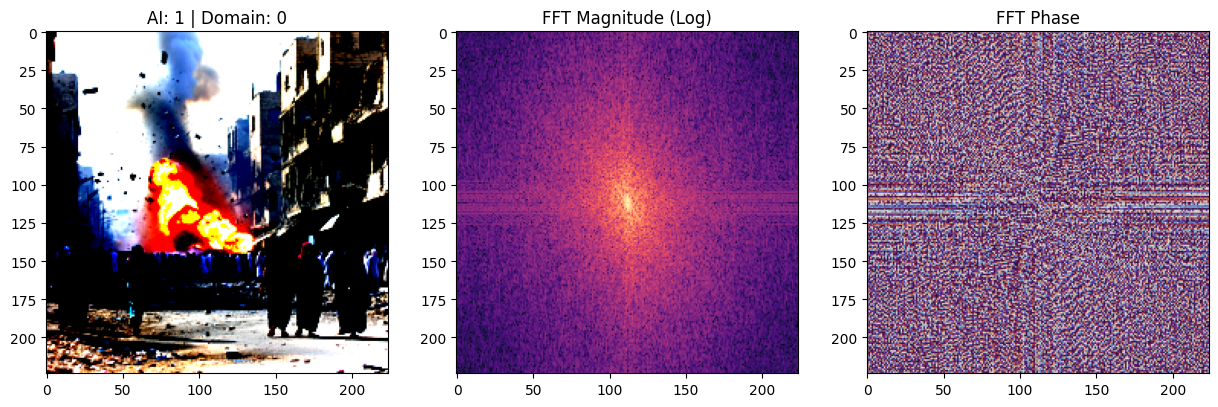

In [17]:
model_preview = FourierNetInput()
images, labels = next(iter(train_loader))
mag, phase = model_preview(images)

index = 0
img_to_show = images[index]
mag_to_show = mag[index]
phs_to_show = phase[index]

img_display = img_to_show.permute(1, 2, 0)
mag_display = mag_to_show[0] # show only the first channel of the magnitude
phs_display = torch.mean(phs_to_show, dim=0)

label_ai_val = labels['label_ai'][index].item()
label_dom_val = labels['label_domain'][index].item()

plt.figure(figsize=(15, 5))

# Original image
plt.subplot(1, 3, 1)
plt.imshow(img_display)
plt.title(f"AI: {label_ai_val} | Domain: {label_dom_val}")

# Magnitude
plt.subplot(1, 3, 2)
plt.imshow(mag_display, cmap='magma')
plt.title("FFT Magnitude (Log)")

# Phase
plt.subplot(1, 3, 3)
plt.imshow(phs_display, cmap='twilight')
plt.title("FFT Phase")

plt.show()


## BackBone

### FourierNet

In [18]:
class FourierNet(nn.Module):
    def __init__(self, feature_dim=EMBEDDING_FOURIER_DIM):
        super().__init__()

        self.fourier_transform = FourierNetInput()

        # 6 input channels: 3 for the magnitude + 3 for the phase
        self.layers = nn.Sequential(
            self._make_layer(6, 32),  # Output: [B, 32, H/2, W/2]
            self._make_layer(32, 64), # Output: [B, 64, H/4, W/4]
            self._make_layer(64, 128) # Output: [B, 128, H/8, W/8]
        )
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1)) # each channel in input is summarized in a tensor of 1x1, namely a single value -> [B, 128, 1, 1]

        # Fully Connected to obtain the informative vector (embedding)
        self.fc_embedding = nn.Sequential(
            nn.Linear(128, feature_dim),
            nn.ReLU(),
            nn.Dropout(0.3)
        )


    def _make_layer(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1), # zero padding (default of padding=1) -> output layer has the same dimension of the input
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2) # halve the spatial dimension of the input layer H/2, W/2
        )

    def forward(self, x):
        # Fourier Transform
        mag, phase = self.fourier_transform(x)

        # Concatenation of the magnitude and the phase along the first dimension (channels)
        x_f = torch.cat((mag, phase), dim=1) # Shape: [B, 6, H, W]

        # Convolutional layers
        x_f = self.layers(x_f)

        # Embedding extraction
        x_f = self.global_pool(x_f)
        x_f = torch.flatten(x_f, 1)  # Output: [B, 128]

        embedding = self.fc_embedding(x_f) # Output: [B, EMBEDDING_FOURIER_DIM]

        return embedding


### RGBNet

In [19]:
class RGBNet(nn.Module):
    def __init__(self, feature_dim= EMBEDDING_RGB_DIM):
        super().__init__()

        # Convolutional Architecture
        self.layers = nn.Sequential(
            self._make_layer(3, 32),   # Output: [B, 32, H/2, W/2]
            self._make_layer(32, 64), # Output: [B, 64, H/4, W/4]
            self._make_layer(64, 128) # Output: [B, 128, H/8, W/8]
        )

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1)) # Output: [B, 128, 1, 1]

        # Fully Connected to obtain the informative vector (embedding)
        self.fc_embedding = nn.Sequential(
            nn.Linear(128, feature_dim),
            nn.GELU(),
            nn.Dropout(0.3)
        )

    def _make_layer(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.GELU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

    def forward(self, x):
        x = self.layers(x)

        # Pooling and Flattening
        x = self.global_pool(x)
        x = torch.flatten(x, 1) # Output: [B, 128]

        # Embedding extraction
        embedding = self.fc_embedding(x) # Output: [B, EMBEDDING_RGB_DIM]

        return embedding


### Merged

In [20]:
class BackBone(nn.Module):
    def __init__(self, final_embedding_dim= EMBEDDING_DIM):
        super().__init__()

        self.fourier_net = FourierNet()
        self.rgb_net = RGBNet()

        feature_dim = EMBEDDING_FOURIER_DIM + EMBEDDING_RGB_DIM
        self.fc_embedding = nn.Sequential(
            nn.Linear(feature_dim, final_embedding_dim),
            nn.GELU(),
            nn.Dropout(0.3)
        )

    def forward(self, x):
        x_f = self.fourier_net(x) # Output [B, feature_dim/2]
        x_rgb = self.rgb_net(x)   # Output [B, feature_dim/2]

        x_c = torch.cat((x_f, x_rgb), dim= 1) # Output [B, feature_dim]

        # Final embedding
        embedding = self.fc_embedding(x_c) # Output [B, EMBEDDING_DIM]

        return embedding


## Two-head Architecture

In [21]:
class BinaryClassifier(nn.Module):
    def __init__(self, embedding_dim: int = EMBEDDING_DIM, hidden_dim: int = 128, dropout: float = 0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(embedding_dim),
            nn.Linear(embedding_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 2)
        )

    def forward(self, x):
        return self.net(x)


class TransformClassifier(nn.Module):
    def __init__(self, embedding_dim: int = EMBEDDING_DIM, hidden_dim: int = 128, dropout: float = 0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(embedding_dim),
            nn.Linear(embedding_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 3)
        )

    def forward(self, x):
        return self.net(x)


class MultiHeadModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.binary_head = BinaryClassifier()
        self.transform_head = TransformClassifier()

    def forward(self, emb_fused):
        logits_binary = self.binary_head(emb_fused)
        logits_transform = self.transform_head(emb_fused)
        return logits_binary, logits_transform


## Final Model

In [22]:
class MultiTaskNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = BackBone()
        self.multi_head = MultiHeadModel()

    def forward(self, x):
        x_emb = self.backbone(x)
        logits_binary, logits_transform = self.multi_head(x_emb)

        return logits_binary, logits_transform


# Quick sanity check / parameter count (uses a freshly initialized model;
# the actual training models below are each initialized independently)
_sanity_model = MultiTaskNet()
model_info(_sanity_model)
del _sanity_model


Parametri Totali:       305,253
Parametri Addestrabili: 305,253
Dimensione (float32):   1.16 MB


# Train

## Lambda Ablation by Design, not as an Afterthought

The combined loss is:

$$\mathcal{L} = \lambda \cdot \mathcal{L}_{AI} + (1-\lambda) \cdot \mathcal{L}_{domain}$$

Rather than training a single model at $\lambda=0.5$ and only later running a separate
ablation, **the training stage itself trains one fully independent `MultiTaskNet`
per value of $\lambda \in \{0.1, 0.3, 0.5, 0.7, 0.9\}$**, each from a fresh random
initialization, each for its own complete training schedule (with its own early
stopping and its own checkpoint). The "main" model and the "ablation" model are
therefore the same set of 5 models — there is no separate, redundant ablation
training step later in the notebook.

**Why not vary $\lambda$ batch-by-batch within a single training run?** Because a
model trained with a $\lambda$ that changes from one batch to the next does not
correspond to any fixed point on the trade-off curve: each gradient step would be
optimizing a different objective, so the resulting weights are a blend that
represents *no particular* trade-off. Such a model could not be meaningfully
compared against "the $\lambda=0.7$ model" or "the $\lambda=0.3$ model", because
no such single objective was ever consistently optimized — making an ablation
study built on it meaningless. The methodologically correct approach — and the one
used here — is to train **one complete, independent model per $\lambda$ value**.


In [ ]:
def train_all_lambda_models(lambda_values, train_loader, val_loader,
                             epochs=EPOCHS, learning_rate=LEARNING_RATE,
                             device=DEVICE, patience=5,
                             checkpoint_dir=CHECKPOINT_DIR):
    """
    Train one fully independent MultiTaskNet per lambda value.

    For each lambda:
      1. A brand-new MultiTaskNet is instantiated (fresh random weights).
      2. It is trained end-to-end with that lambda fixed for the entire run.
      3. Its own best checkpoint (lowest val_loss) is saved separately.
      4. Its training history is kept for later learning-curve plots.

    Returns
    -------
    models      : dict {lambda: trained MultiTaskNet (best checkpoint loaded)}
    histories   : dict {lambda: history dict from train_multitask_model}
    checkpoints : dict {lambda: path to the saved .pth file}
    """
    models, histories, checkpoints = {}, {}, {}

    for lam in lambda_values:
        print("\n" + "=" * 70)
        print(f"  TRAINING INDEPENDENT MODEL  —  λ = {lam}")
        print("=" * 70)

        torch.manual_seed(SEED)  # same init scheme across runs, fair comparison
        model = MultiTaskNet()

        ckpt_path = checkpoint_dir / f"model_lambda_{lam}.pth"

        history = train_multitask_model(
            model, train_loader, val_loader,
            epochs=epochs, learning_rate=learning_rate, device=device,
            weight_task=lam, checkpoint_path=str(ckpt_path), patience=patience,
        )

        # Reload the best checkpoint for this lambda (lowest val_loss epoch)
        model.load_state_dict(torch.load(ckpt_path, map_location=device))
        model.to(device)

        models[lam]      = model
        histories[lam]   = history
        checkpoints[lam] = ckpt_path

        best_epoch = int(np.argmin(history['val_loss']))
        print(f"[λ={lam}] Best checkpoint @ epoch {best_epoch+1} "
              f"(val_loss={history['val_loss'][best_epoch]:.4f}, "
              f"val_acc_ai={history['val_acc_ai'][best_epoch]*100:.2f}%, "
              f"val_acc_domain={history['val_acc_domain'][best_epoch]*100:.2f}%)")

    return models, histories, checkpoints

trained_models, training_histories, model_checkpoints = train_all_lambda_models(
    LAMBDA_VALUES, train_loader, val_loader, epochs=EPOCHS, device=DEVICE
)



  TRAINING INDEPENDENT MODEL  —  λ = 0.1


[λ=0.1] Epoch [1/50] - Train: 100%|██████████| 105/105 [02:00<00:00,  1.15s/it, loss=0.973]


--- [λ=0.1] Epoch 1 ---
Training Loss:   1.0413
Validation Loss: 0.9516
Val Accuracy AI: 59.51% | Val Accuracy Domain: 49.96%



[λ=0.1] Epoch [2/50] - Train: 100%|██████████| 105/105 [01:59<00:00,  1.13s/it, loss=0.854]


--- [λ=0.1] Epoch 2 ---
Training Loss:   0.9155
Validation Loss: 0.8406
Val Accuracy AI: 63.69% | Val Accuracy Domain: 54.93%

Validation loss diminuita (0.9516 --> 0.8406). Salvo il modello!


...

--- [λ=0.9] Epoch 23 ---
Training Loss:   0.4236
Validation Loss: 0.4625
Val Accuracy AI: 81.42% | Val Accuracy Domain: 58.09%

EarlyStopping counter: 3 out of 5


[λ=0.9] Epoch [24/50] - Train: 100%|██████████| 105/105 [01:57<00:00,  1.12s/it, loss=0.388]


--- [λ=0.9] Epoch 24 ---
Training Loss:   0.4233
Validation Loss: 0.5023
Val Accuracy AI: 78.00% | Val Accuracy Domain: 59.29%

EarlyStopping counter: 4 out of 5


[λ=0.9] Epoch [25/50] - Train: 100%|██████████| 105/105 [01:57<00:00,  1.12s/it, loss=0.488]
                                                                            

--- [λ=0.9] Epoch 25 ---
Training Loss:   0.4220
Validation Loss: 0.4840
Val Accuracy AI: 79.78% | Val Accuracy Domain: 59.02%

EarlyStopping counter: 5 out of 5
[λ=0.9] Early stopping triggered...
[λ=0.9] Training Completed
[λ=0.9] Best checkpoint @ epoch 20 (val_loss=0.4339, val_acc_ai=82.40%, val_acc_domain=57.73%)


In [ ]:
histories_serializable = {str(lam): hist for lam, hist in training_histories.items()}

with open(CHECKPOINT_DIR / "training_histories.json", "w") as f:
    json.dump(histories_serializable, f)
print("Successfully Saved Training Stories!")

In [23]:
trained_models = {}
model_checkpoints = {}

print("Loading multi-task models from checkpoints...")
for lam in LAMBDA_VALUES:
    
    model = MultiTaskNet()
    ckpt_path = CHECKPOINT_DIR / f"model_lambda_{lam}.pth"
    
    
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()
    
    trained_models[lam] = model
    model_checkpoints[lam] = ckpt_path
    print(f" -> Model λ={lam} loaded successfully.")
    
try:
    with open(CHECKPOINT_DIR / "training_histories.json", "r") as f:
        histories_loaded = json.load(f)
    
    training_histories = {float(lam): hist for lam, hist in histories_loaded.items()}
    print("\nTraining histories loaded successfully!")
except FileNotFoundError:
    training_histories = {}
    print("\n[WARNING] Training histories file not found. You will not be able to plot the Learning Curves, but you can proceed with the rest of the Evaluation.")

Loading multi-task models from checkpoints...
 -> Model λ=0.1 loaded successfully.
 -> Model λ=0.3 loaded successfully.
 -> Model λ=0.5 loaded successfully.
 -> Model λ=0.7 loaded successfully.
 -> Model λ=0.9 loaded successfully.

[WARNING] Training histories file not found. You will not be able to plot the Learning Curves, but you can proceed with the rest of the Evaluation.


# Evaluation

## Learning Curves — One per Lambda

Training/validation loss and validation accuracy curves for every independently
trained model, shown side by side so the optimization dynamics can be compared
across the lambda grid.

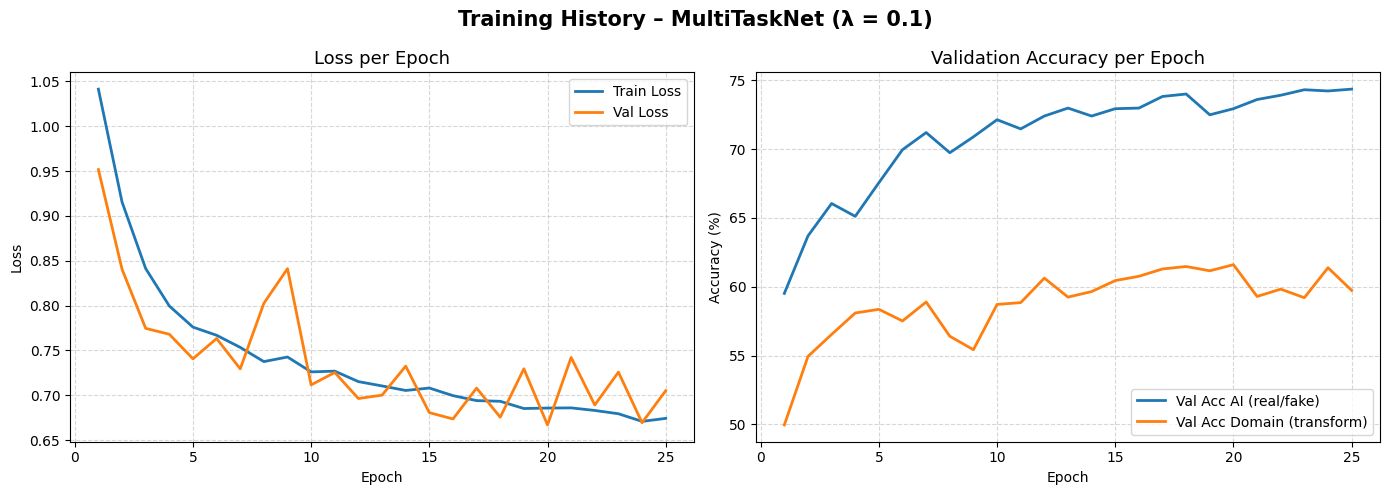

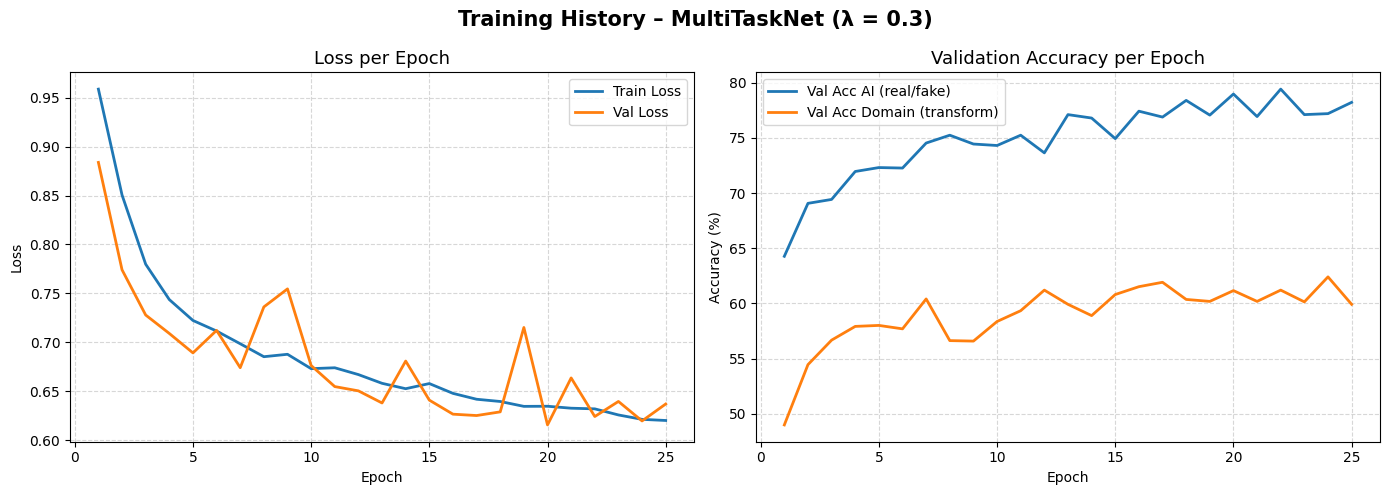

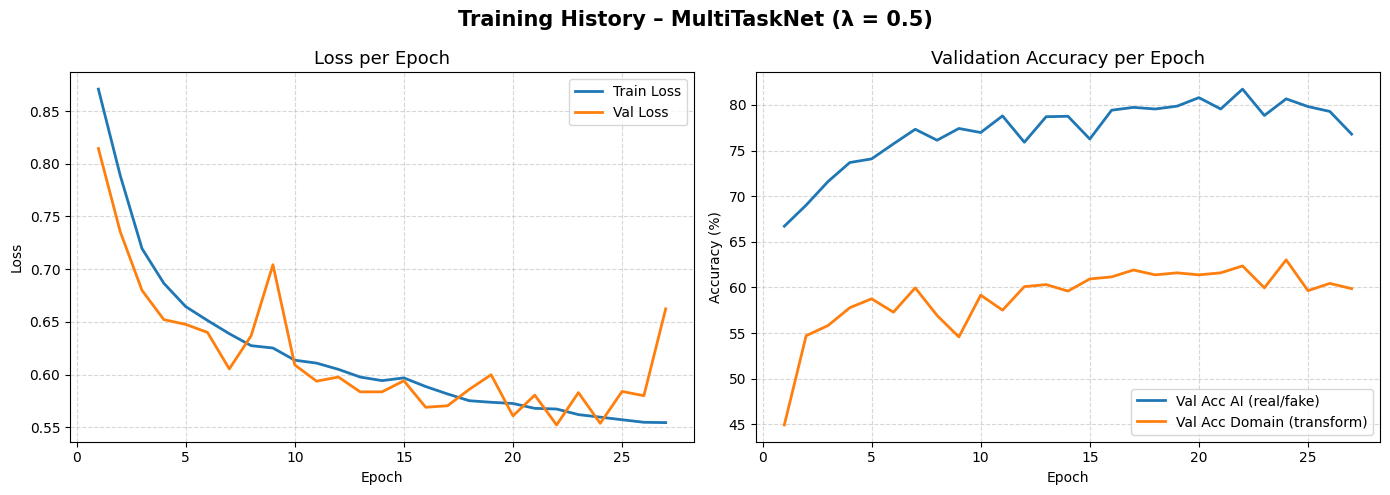

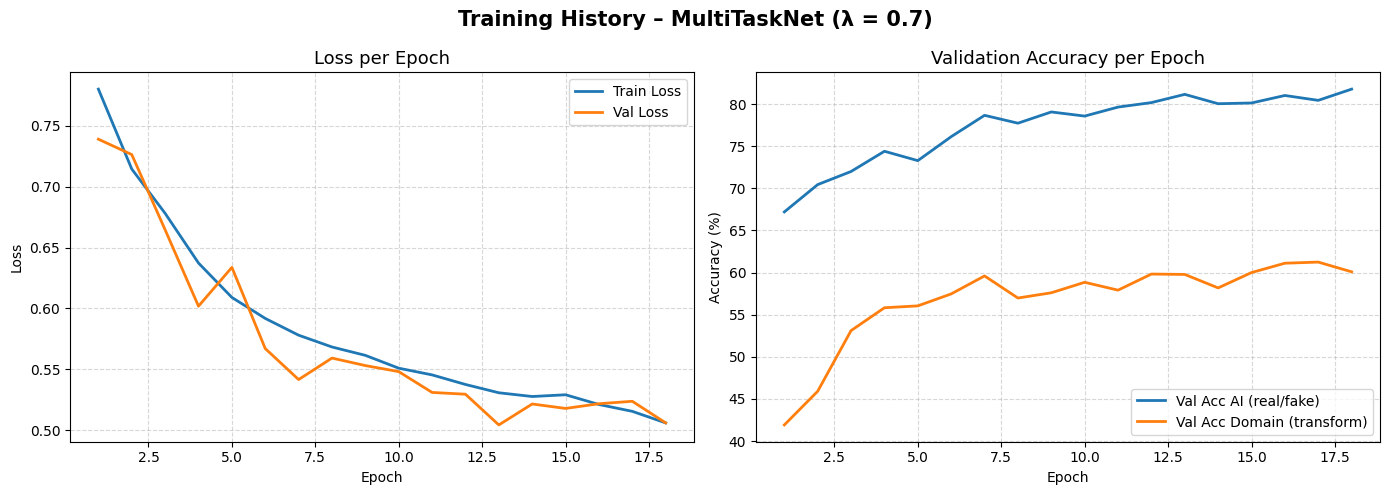

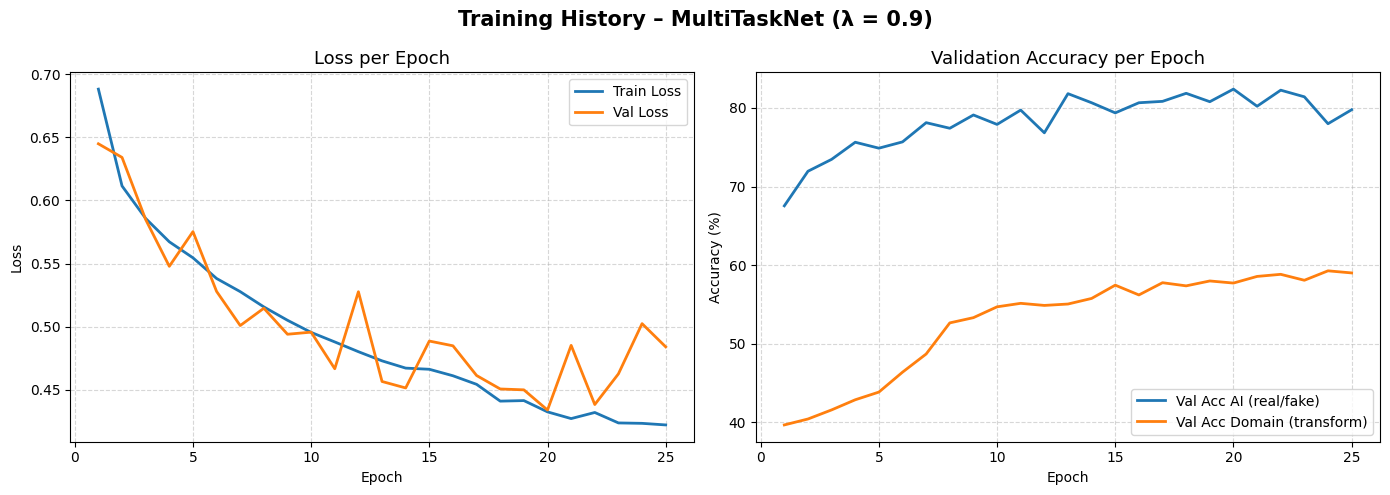

In [16]:
def plot_learning_curves(history, title_suffix=""):
    epochs_ran = range(1, len(history['train_loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # — Loss —
    axes[0].plot(epochs_ran, history['train_loss'], label='Train Loss', linewidth=2)
    axes[0].plot(epochs_ran, history['val_loss'],   label='Val Loss',   linewidth=2)
    axes[0].set_title('Loss per Epoch', fontsize=13)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.5)

    # — Accuracy —
    axes[1].plot(epochs_ran, [a*100 for a in history['val_acc_ai']],
                 label='Val Acc AI (real/fake)', linewidth=2)
    axes[1].plot(epochs_ran, [a*100 for a in history['val_acc_domain']],
                 label='Val Acc Domain (transform)', linewidth=2)
    axes[1].set_title('Validation Accuracy per Epoch', fontsize=13)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.5)

    plt.suptitle(f'Training History – MultiTaskNet {title_suffix}', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()


for lam in LAMBDA_VALUES:
    plot_learning_curves(training_histories[lam], title_suffix=f"(λ = {lam})")


## Test-Set Inference — One Pass per Lambda

Each of the 5 independently trained models is evaluated on the **same held-out
test set**, producing one prediction dictionary per lambda (true/predicted
labels and softmax probabilities for both tasks).

In [24]:
test_predictions = {}

for lam in LAMBDA_VALUES:
    print(f"\n>>> Running test-set inference for λ = {lam}")
    test_predictions[lam] = collect_predictions(trained_models[lam], test_loader, device=DEVICE)

print("\nTest inference completed for all lambda values.")



>>> Running test-set inference for λ = 0.1


Inference: 100%|██████████| 23/23 [00:27<00:00,  1.18s/it]



>>> Running test-set inference for λ = 0.3


Inference: 100%|██████████| 23/23 [00:25<00:00,  1.11s/it]



>>> Running test-set inference for λ = 0.5


...


>>> Running test-set inference for λ = 0.7


Inference: 100%|██████████| 23/23 [00:25<00:00,  1.10s/it]



>>> Running test-set inference for λ = 0.9


Inference: 100%|██████████| 23/23 [00:25<00:00,  1.11s/it]


Test inference completed for all lambda values.


## Confusion Matrices — Per Lambda

For every lambda, two confusion matrices: one for the **AI-detection** head
(real vs fake) and one for the **transformation** head (original /
internet-transmitted / re-digitized).

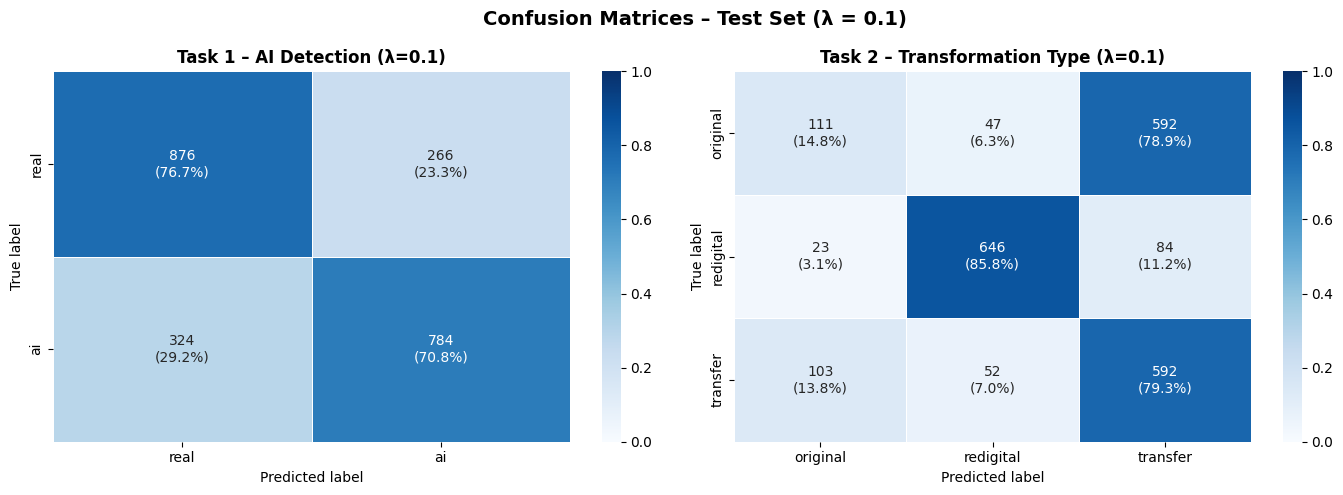

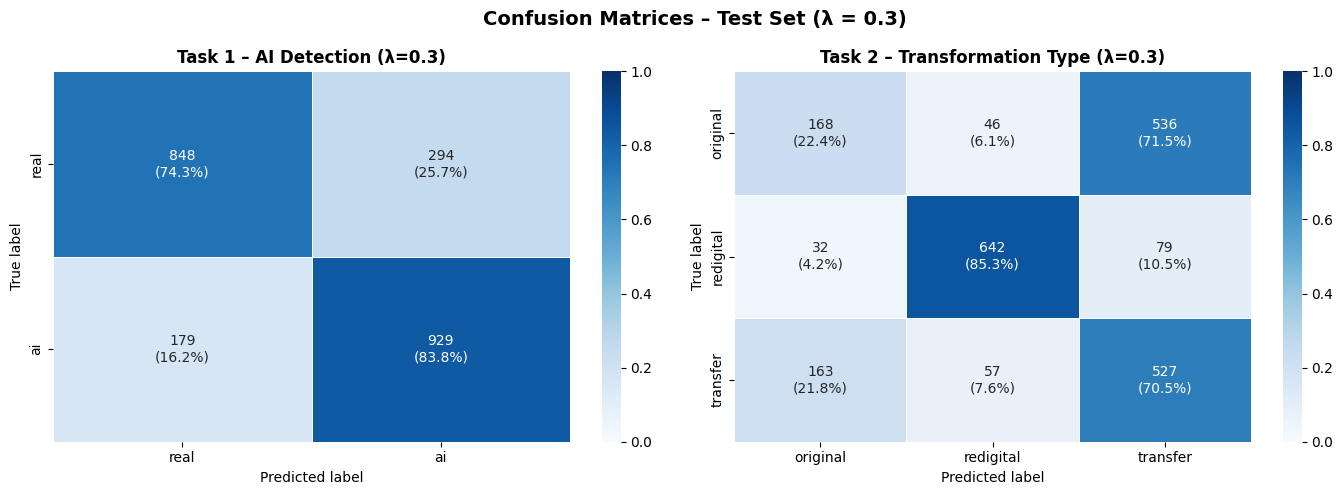

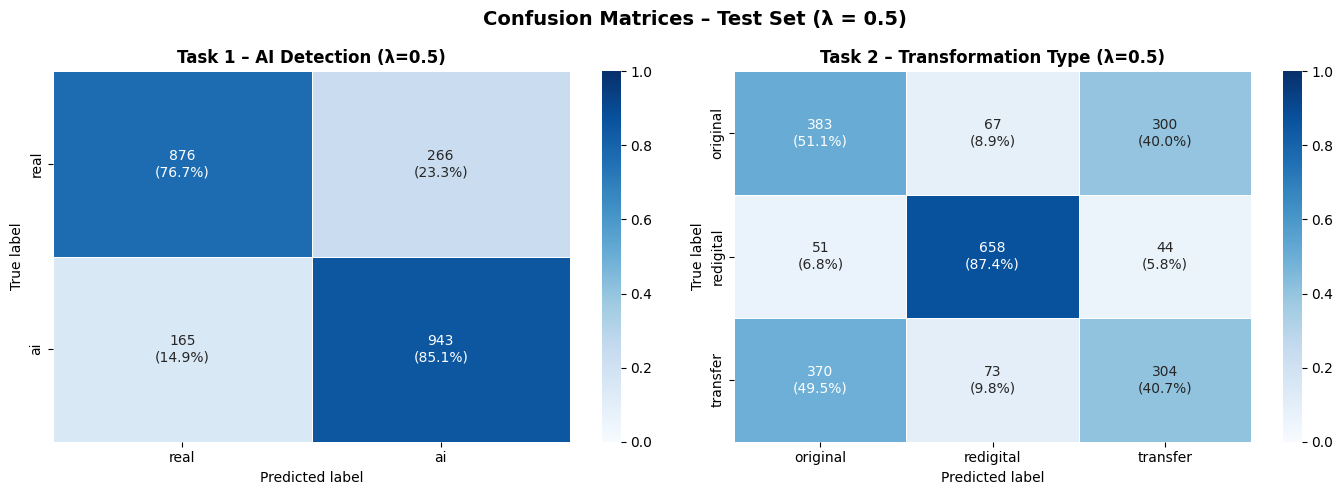

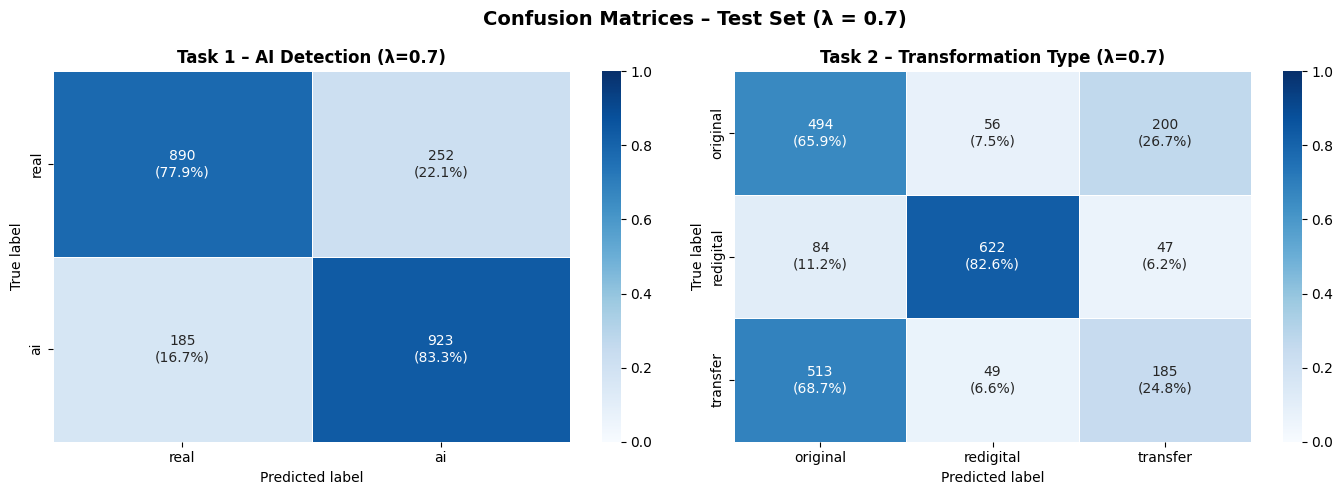

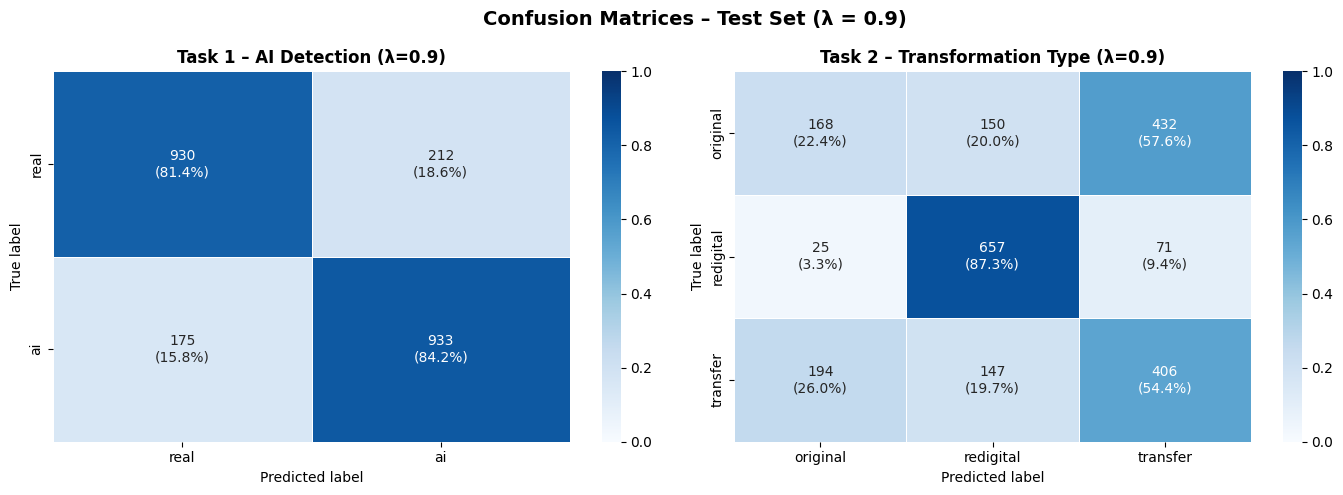

In [25]:
def plot_confusion_matrix(y_true, y_pred, class_names, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # row-normalised

    annot = np.array(
        [[f"{cm[i,j]}\n({cm_norm[i,j]*100:.1f}%)"
          for j in range(cm.shape[1])]
         for i in range(cm.shape[0])]
    )

    sns.heatmap(
        cm_norm, annot=annot, fmt='', cmap='Blues',
        xticklabels=class_names, yticklabels=class_names,
        vmin=0, vmax=1, ax=ax, linewidths=.5
    )
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')


for lam in LAMBDA_VALUES:
    preds = test_predictions[lam]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    plot_confusion_matrix(preds['true_ai'],     preds['pred_ai'],
                          AI_LABELS,     f'Task 1 – AI Detection (λ={lam})', axes[0])
    plot_confusion_matrix(preds['true_domain'], preds['pred_domain'],
                          DOMAIN_LABELS, f'Task 2 – Transformation Type (λ={lam})', axes[1])
    plt.suptitle(f'Confusion Matrices – Test Set (λ = {lam})', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


## Classification Reports — Per Lambda

In [26]:
for lam in LAMBDA_VALUES:
    preds = test_predictions[lam]
    print('=' * 60)
    print(f'λ = {lam}  |  TASK 1 – AI Detection (real vs fake)')
    print('=' * 60)
    print(classification_report(preds['true_ai'], preds['pred_ai'],
                                  target_names=AI_LABELS, digits=4))

    print('=' * 60)
    print(f'λ = {lam}  |  TASK 2 – Transformation Type Classification')
    print('=' * 60)
    print(classification_report(preds['true_domain'], preds['pred_domain'],
                                  target_names=DOMAIN_LABELS, digits=4))
    print()


λ = 0.1  |  TASK 1 – AI Detection (real vs fake)
              precision    recall  f1-score   support

        real     0.7300    0.7671    0.7481      1142
          ai     0.7467    0.7076    0.7266      1108

    accuracy                         0.7378      2250
   macro avg     0.7383    0.7373    0.7373      2250
weighted avg     0.7382    0.7378    0.7375      2250

λ = 0.1  |  TASK 2 – Transformation Type Classification
              precision    recall  f1-score   support

    original     0.4684    0.1480    0.2249       750
   redigital     0.8671    0.8579    0.8625       753
    transfer     0.4669    0.7925    0.5876       747

    accuracy                         0.5996      2250
   macro avg     0.6008    0.5995    0.5583      2250
weighted avg     0.6013    0.5996    0.5587      2250


λ = 0.3  |  TASK 1 – AI Detection (real vs fake)
              precision    recall  f1-score   support

        real     0.8257    0.7426    0.7819      1142
          ai     0.7596    0

## ROC Curves and AUC — Per Lambda

One-vs-rest ROC curve for each class in both tasks, for every trained model.

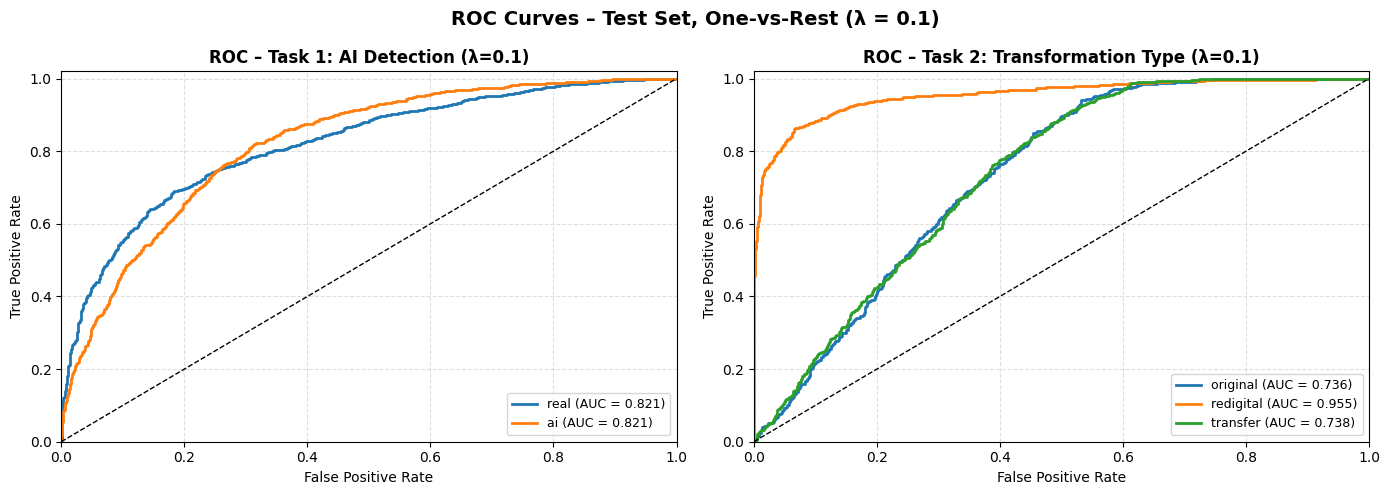

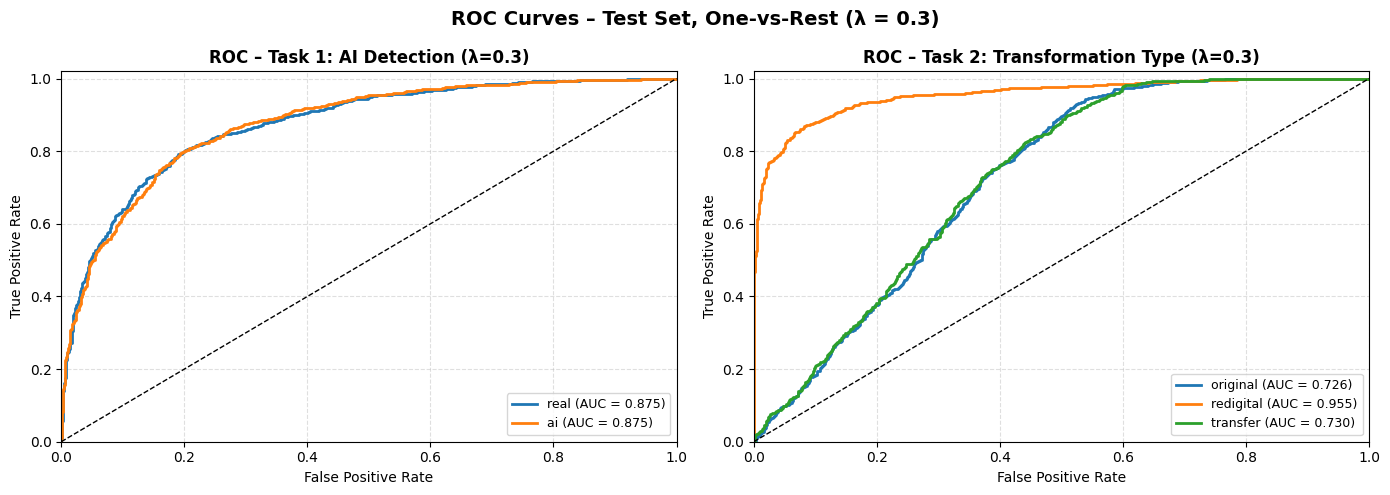

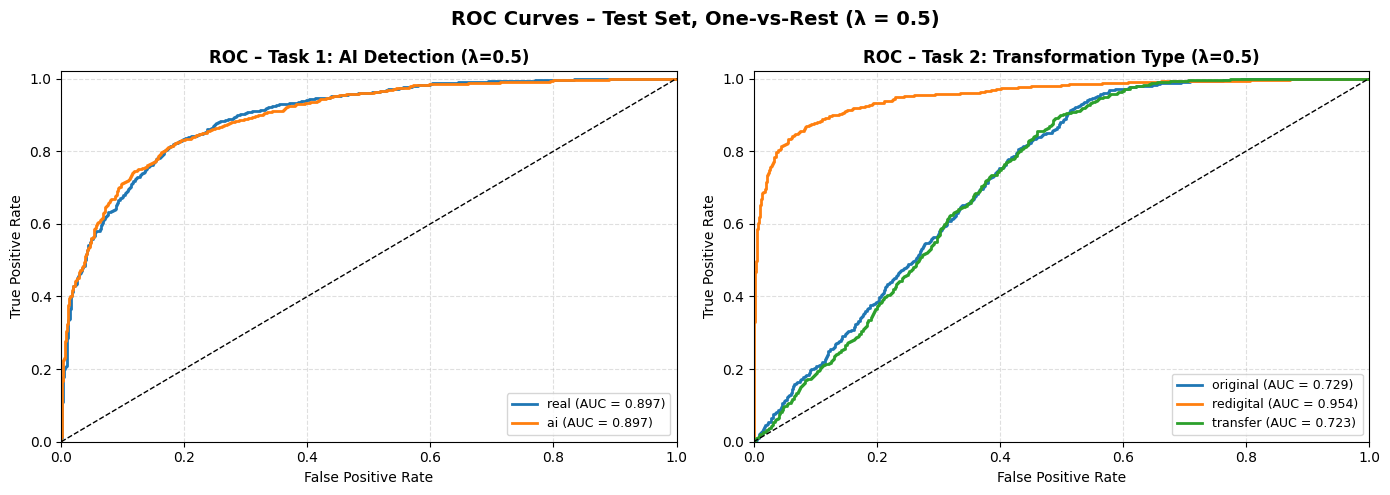

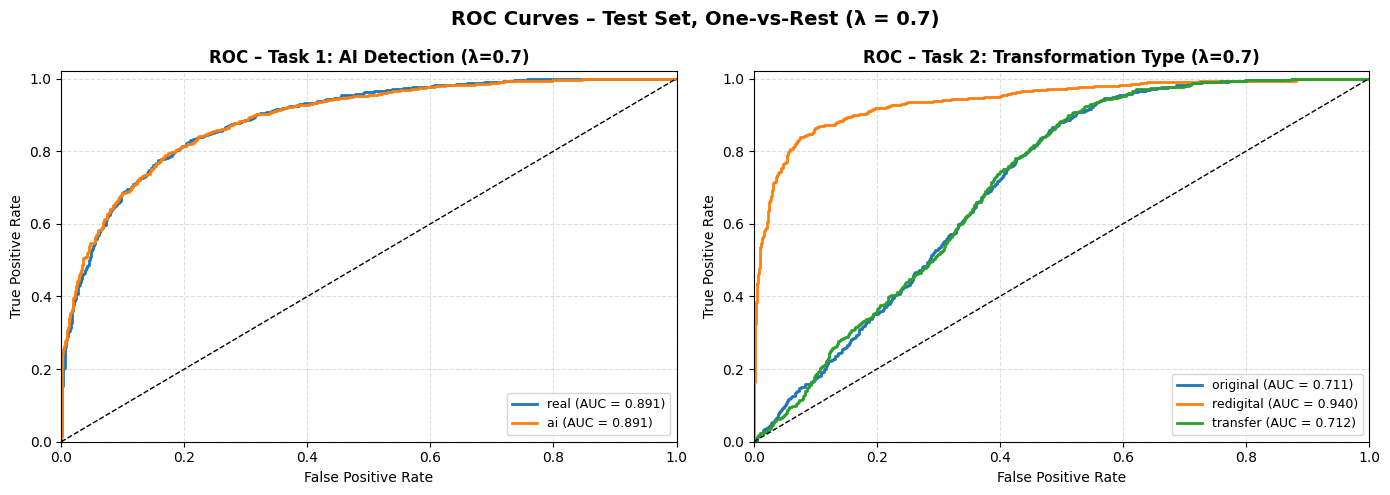

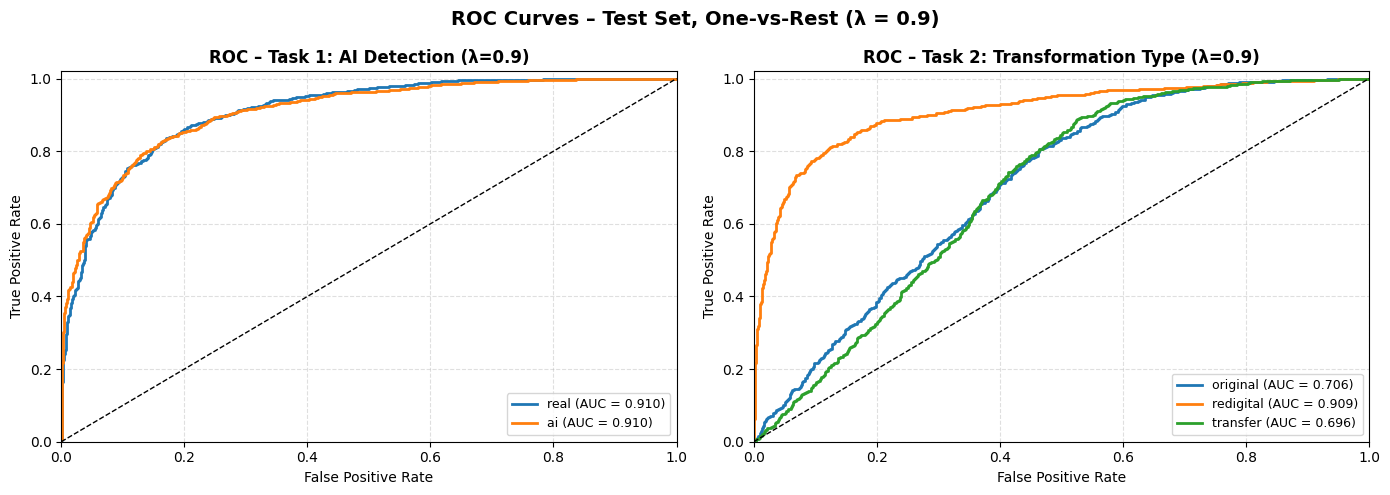

In [27]:
def plot_roc_curves(y_true, y_prob, class_names, title, ax):
    n_classes = len(class_names)
    colors = plt.cm.tab10.colors

    if n_classes == 2:
        # label_binarize collapses the binary case to a single column
        # (the positive-class indicator), instead of one column per class.
        # We rebuild both columns explicitly so the loop below works the
        # same way regardless of n_classes.
        y_bin = np.zeros((len(y_true), 2))
        y_bin[:, 1] = (np.asarray(y_true) == 1).astype(int)
        y_bin[:, 0] = 1 - y_bin[:, 1]
    else:
        y_bin = label_binarize(y_true, classes=list(range(n_classes)))

    for c in range(n_classes):
        fpr, tpr, _ = roc_curve(y_bin[:, c], y_prob[:, c])
        roc_auc     = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=colors[c], linewidth=2,
                label=f'{class_names[c]} (AUC = {roc_auc:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)


for lam in LAMBDA_VALUES:
    preds = test_predictions[lam]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    plot_roc_curves(preds['true_ai'],     preds['prob_ai'],
                    AI_LABELS,     f'ROC – Task 1: AI Detection (λ={lam})',       axes[0])
    plot_roc_curves(preds['true_domain'], preds['prob_domain'],
                    DOMAIN_LABELS, f'ROC – Task 2: Transformation Type (λ={lam})', axes[1])
    plt.suptitle(f'ROC Curves – Test Set, One-vs-Rest (λ = {lam})', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Per-Class Metrics Bar Chart — Per Lambda

Precision, Recall and F1-Score for each class, for both tasks, for every
trained model.

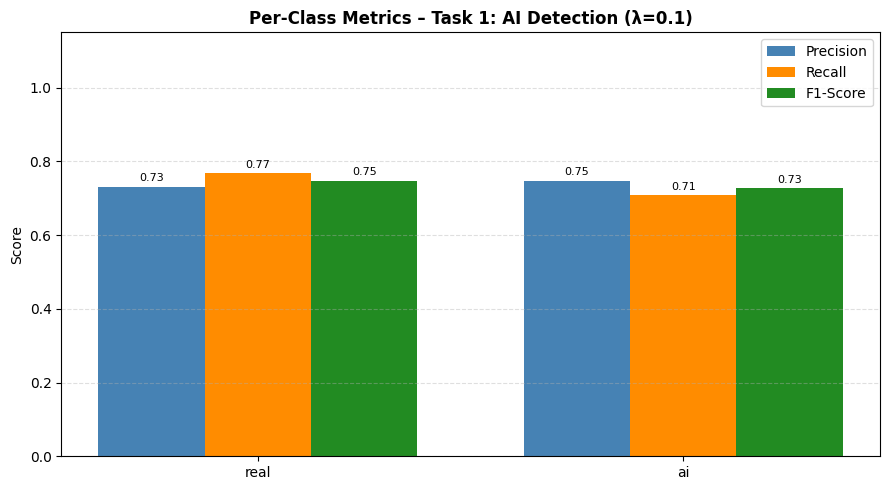

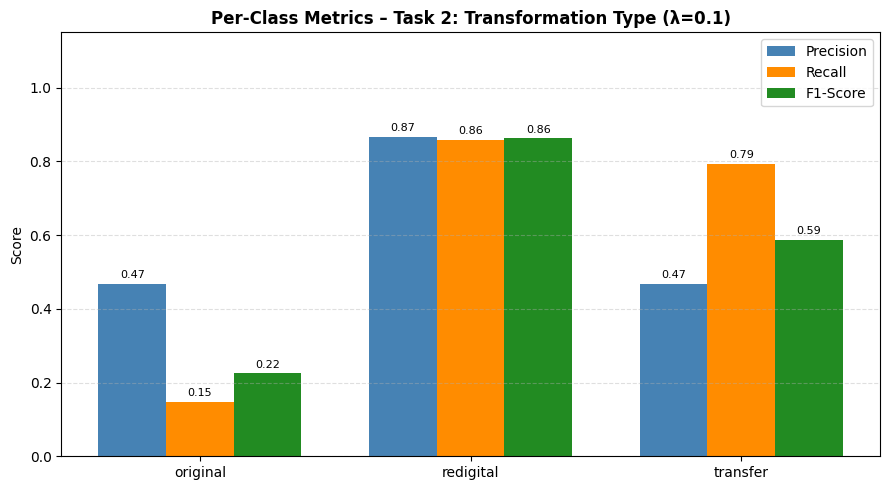

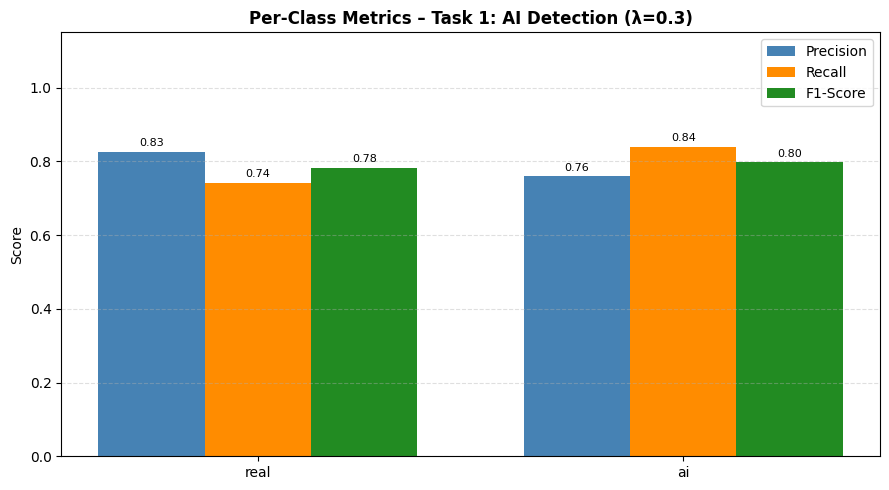

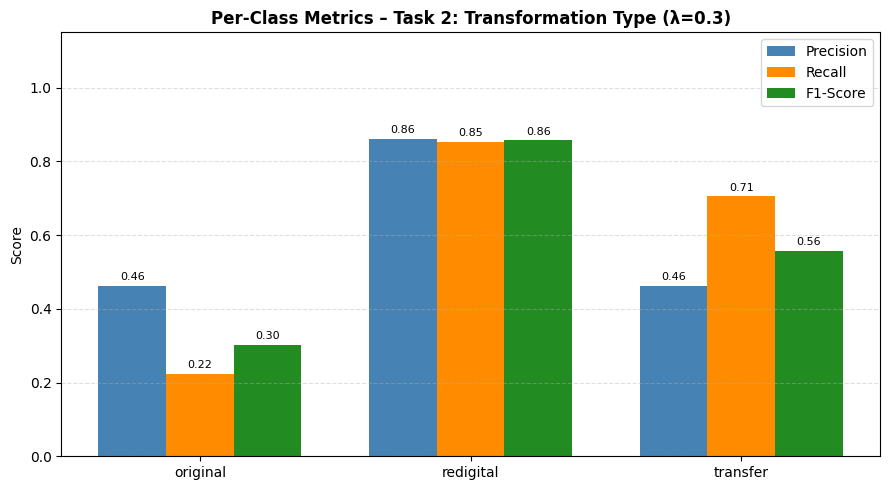

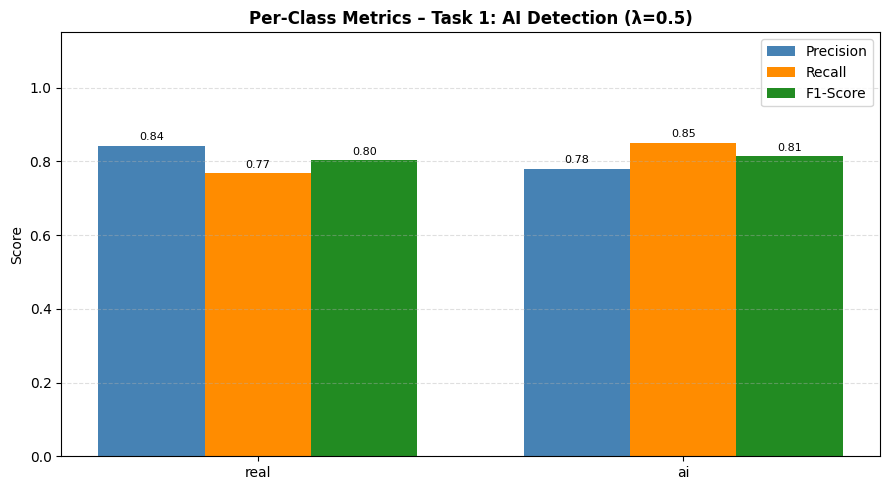

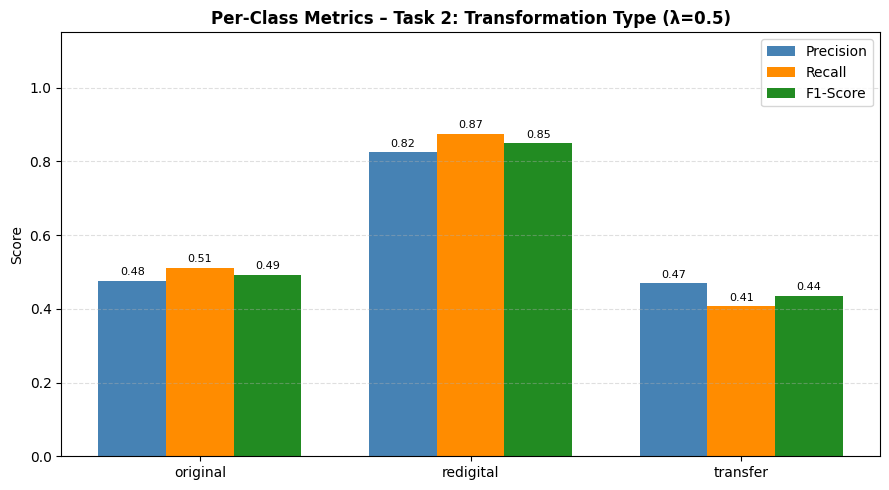

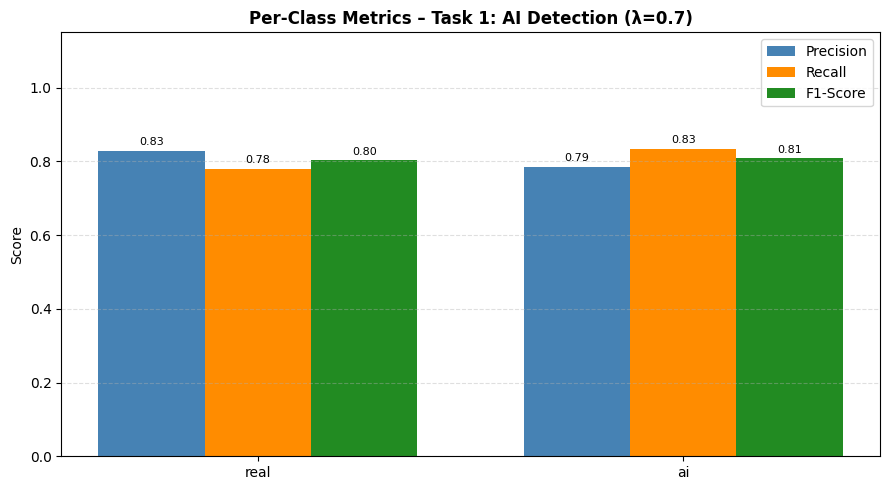

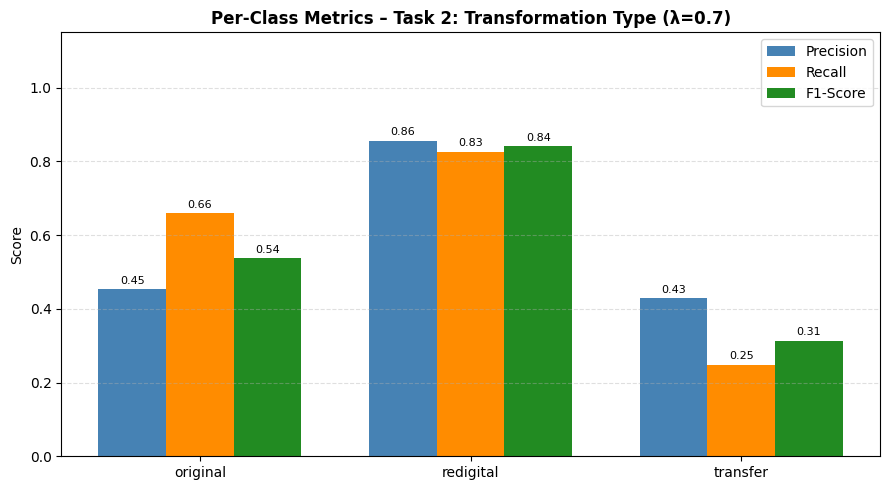

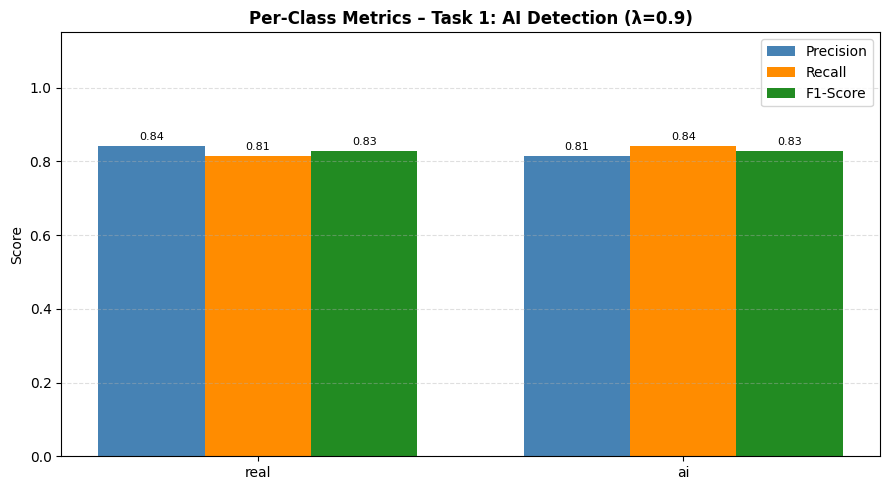

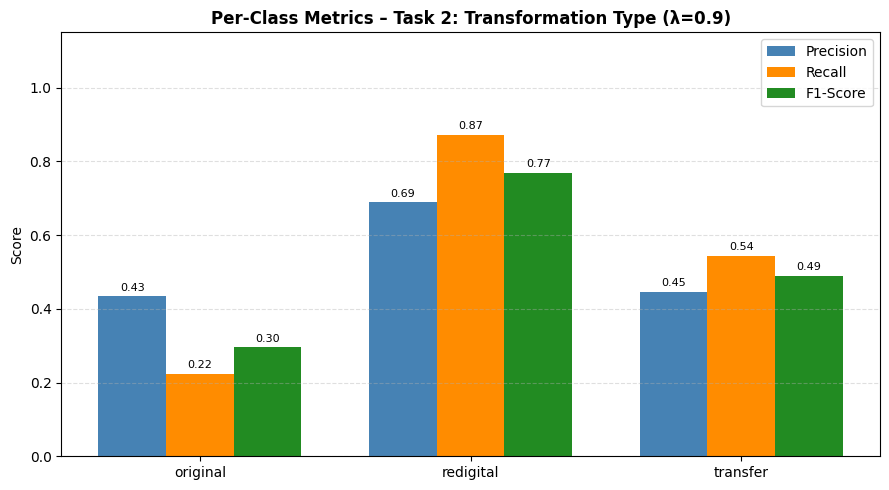

In [28]:
def plot_per_class_metrics(y_true, y_pred, class_names, title):
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=list(range(len(class_names))), average=None
    )

    x      = np.arange(len(class_names))
    width  = 0.25

    fig, ax = plt.subplots(figsize=(9, 5))
    b1 = ax.bar(x - width, prec, width, label='Precision', color='steelblue')
    b2 = ax.bar(x,          rec,  width, label='Recall',    color='darkorange')
    b3 = ax.bar(x + width, f1,   width, label='F1-Score',  color='forestgreen')

    for bars in [b1, b2, b3]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01,
                    f'{h:.2f}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(class_names)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Score')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()


for lam in LAMBDA_VALUES:
    preds = test_predictions[lam]
    plot_per_class_metrics(preds['true_ai'],     preds['pred_ai'],
                           AI_LABELS,     f'Per-Class Metrics – Task 1: AI Detection (λ={lam})')
    plot_per_class_metrics(preds['true_domain'], preds['pred_domain'],
                           DOMAIN_LABELS, f'Per-Class Metrics – Task 2: Transformation Type (λ={lam})')


## Accuracy Breakdown by Transformation Category — Per Lambda

For **Task 1 (AI detection)**, accuracy measured *separately* for each
post-processing category (original, redigital, transfer), for every trained
model. This reveals which transformations are most harmful to detection
performance, and whether that pattern shifts as lambda changes.


--- λ = 0.1 ---


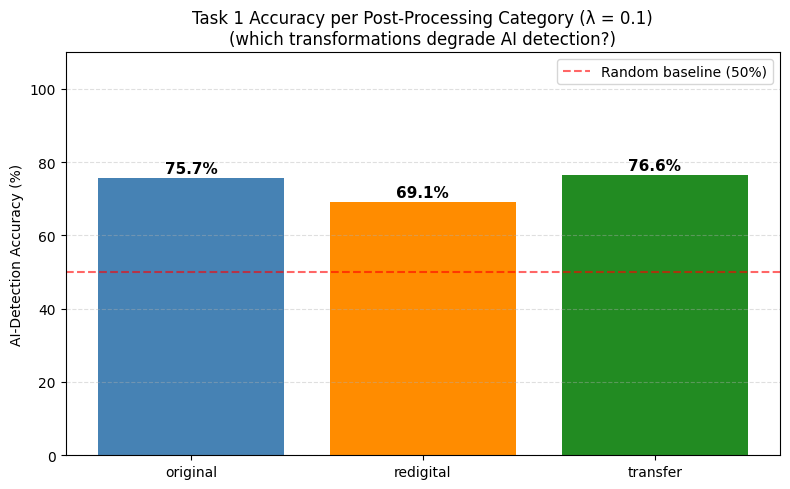

  original    : 75.73%
  redigital   : 69.06%
  transfer    : 76.57%

--- λ = 0.3 ---


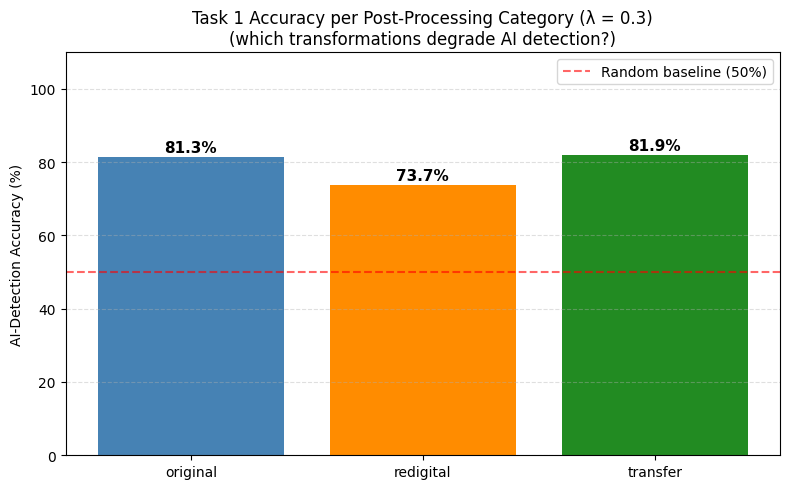

  original    : 81.33%
  redigital   : 73.71%
  transfer    : 81.93%

--- λ = 0.5 ---


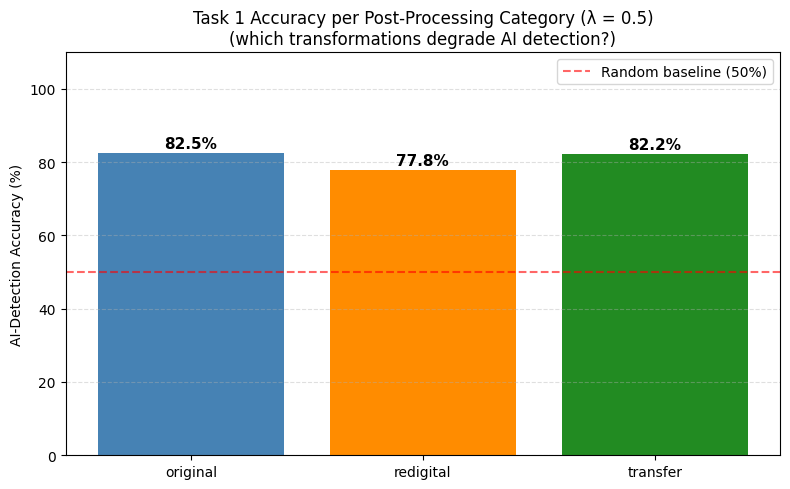

  original    : 82.53%
  redigital   : 77.82%
  transfer    : 82.20%

--- λ = 0.7 ---


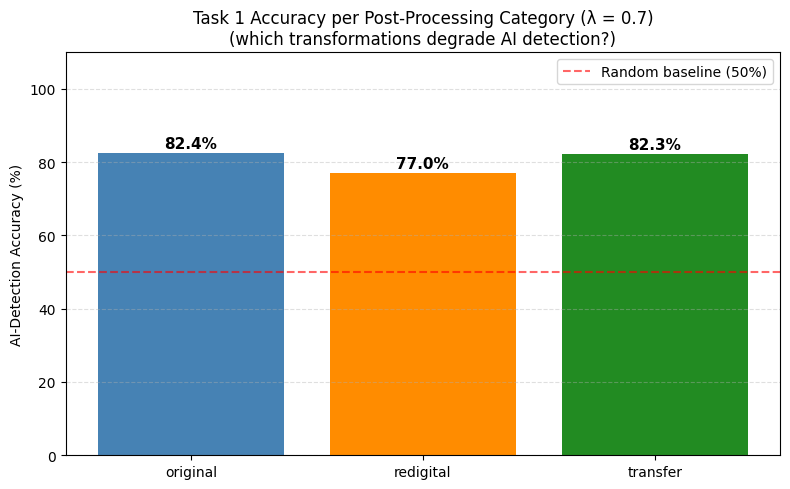

  original    : 82.40%
  redigital   : 77.03%
  transfer    : 82.33%

--- λ = 0.9 ---


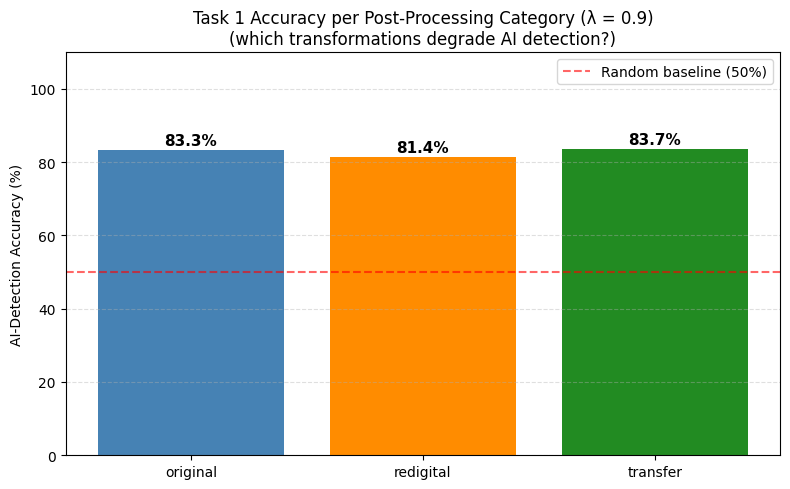

  original    : 83.33%
  redigital   : 81.41%
  transfer    : 83.67%


In [29]:
def plot_accuracy_by_domain(true_ai, pred_ai, true_domain, domain_names, title_suffix=""):
    """Bar chart: AI-detection accuracy split by transformation category."""
    accs = {}
    for d_idx, d_name in enumerate(domain_names):
        mask = (true_domain == d_idx)
        if mask.sum() == 0:
            accs[d_name] = 0.0
            continue
        accs[d_name] = accuracy_score(true_ai[mask], pred_ai[mask])

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(list(accs.keys()), [v*100 for v in accs.values()],
                  color=['steelblue', 'darkorange', 'forestgreen'])
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.axhline(y=50, color='red', linestyle='--', alpha=0.6, label='Random baseline (50%)')
    ax.set_ylim(0, 110)
    ax.set_ylabel('AI-Detection Accuracy (%)')
    ax.set_title(f'Task 1 Accuracy per Post-Processing Category {title_suffix}\n'
                 '(which transformations degrade AI detection?)', fontsize=12)
    ax.legend()
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

    return accs


per_domain_accuracy = {}  # {lambda: {domain_name: acc}}
for lam in LAMBDA_VALUES:
    preds = test_predictions[lam]
    print(f"\n--- λ = {lam} ---")
    accs = plot_accuracy_by_domain(
        preds['true_ai'], preds['pred_ai'],
        preds['true_domain'], DOMAIN_LABELS,
        title_suffix=f"(λ = {lam})"
    )
    per_domain_accuracy[lam] = accs
    for name, acc in accs.items():
        print(f'  {name:12s}: {acc*100:.2f}%')


## Aggregate Comparison Across Lambda Values

Everything below is computed from the test-set evaluations already collected
for each of the 5 independently trained models — there is no additional
training here. This is the final, complete picture of the $\lambda$
trade-off: overall accuracy, full per-class precision/recall/F1, and the
per-transformation breakdown, all side by side across the grid.

In [30]:
def build_lambda_summary_table(test_predictions, lambda_values):
    """Overall test accuracy (Task 1 & Task 2) for every lambda."""
    rows = []
    for lam in lambda_values:
        preds = test_predictions[lam]
        acc_ai     = accuracy_score(preds['true_ai'],     preds['pred_ai'])
        acc_domain = accuracy_score(preds['true_domain'], preds['pred_domain'])
        rows.append((lam, acc_ai, acc_domain))
    return rows


summary_rows = build_lambda_summary_table(test_predictions, LAMBDA_VALUES)

print('─' * 60)
print(f'{"λ":>6} | {"Test Acc – AI (Task 1)":>24} | {"Test Acc – Domain (Task 2)":>26}')
print('─' * 60)
for lam, acc_ai, acc_domain in summary_rows:
    print(f'{lam:>6.1f} | {acc_ai*100:>23.2f}% | {acc_domain*100:>25.2f}%')


────────────────────────────────────────────────────────────
     λ |   Test Acc – AI (Task 1) | Test Acc – Domain (Task 2)
────────────────────────────────────────────────────────────
   0.1 |                   73.78% |                     59.96%
   0.3 |                   78.98% |                     59.42%
   0.5 |                   80.84% |                     59.78%
   0.7 |                   80.58% |                     57.82%
   0.9 |                   82.80% |                     54.71%


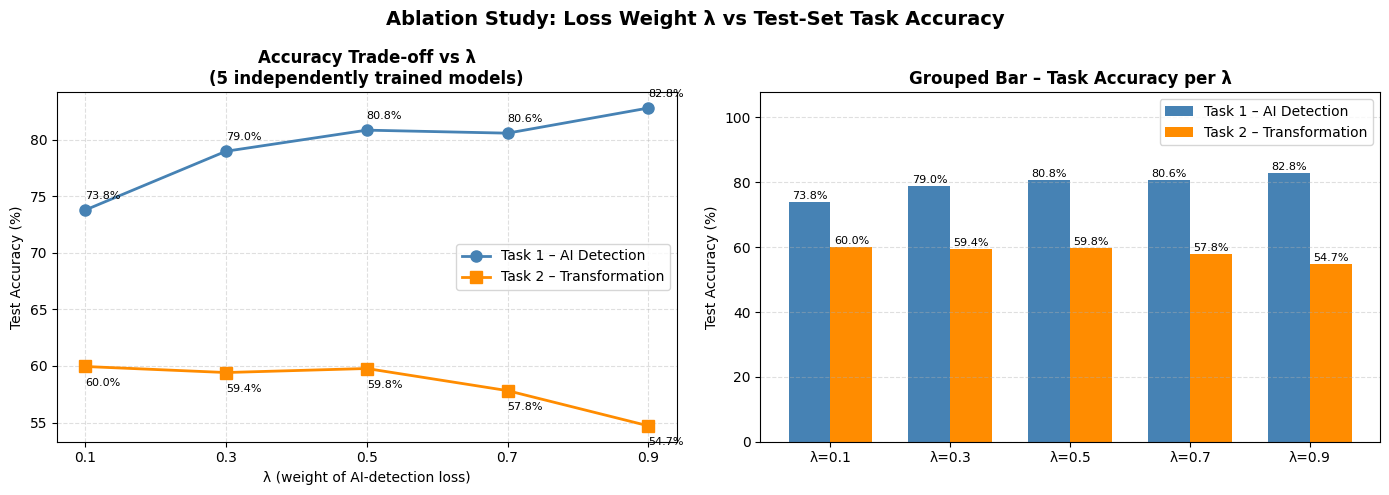

In [37]:
def plot_lambda_tradeoff(summary_rows):
    lambdas    = [r[0] for r in summary_rows]
    acc_ai     = [r[1] * 100 for r in summary_rows]
    acc_domain = [r[2] * 100 for r in summary_rows]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Line plot ──────────────────────────────────────────────────────────
    axes[0].plot(lambdas, acc_ai,     'o-', color='steelblue',  linewidth=2, markersize=8,
                 label='Task 1 – AI Detection')
    axes[0].plot(lambdas, acc_domain, 's-', color='darkorange', linewidth=2, markersize=8,
                 label='Task 2 – Transformation')
    for lam, a, b in zip(lambdas, acc_ai, acc_domain):
        axes[0].annotate(f'{a:.1f}%', (lam, a), textcoords='offset points', xytext=(0, 8),   fontsize=8)
        axes[0].annotate(f'{b:.1f}%', (lam, b), textcoords='offset points', xytext=(0, -14), fontsize=8)
    axes[0].set_xlabel('λ (weight of AI-detection loss)')
    axes[0].set_ylabel('Test Accuracy (%)')
    axes[0].set_title('Accuracy Trade-off vs λ\n(5 independently trained models)', fontsize=12, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.4)
    axes[0].set_xticks(lambdas)

    # ── Grouped bar chart ─────────────────────────────────────────────────
    x     = np.arange(len(lambdas))
    width = 0.35
    b1 = axes[1].bar(x - width/2, acc_ai,     width, label='Task 1 – AI Detection',   color='steelblue')
    b2 = axes[1].bar(x + width/2, acc_domain, width, label='Task 2 – Transformation', color='darkorange')
    for bars in [b1, b2]:
        for bar in bars:
            h = bar.get_height()
            axes[1].text(bar.get_x() + bar.get_width()/2, h + 0.3,
                         f'{h:.1f}%', ha='center', va='bottom', fontsize=8)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([f'λ={lam}' for lam in lambdas])
    axes[1].set_ylabel('Test Accuracy (%)')
    axes[1].set_title('Grouped Bar – Task Accuracy per λ', fontsize=12, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, axis='y', linestyle='--', alpha=0.4)
    axes[1].set_ylim(0, max(max(acc_ai), max(acc_domain)) + 25)
    
    plt.suptitle('Ablation Study: Loss Weight λ vs Test-Set Task Accuracy', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


plot_lambda_tradeoff(summary_rows)


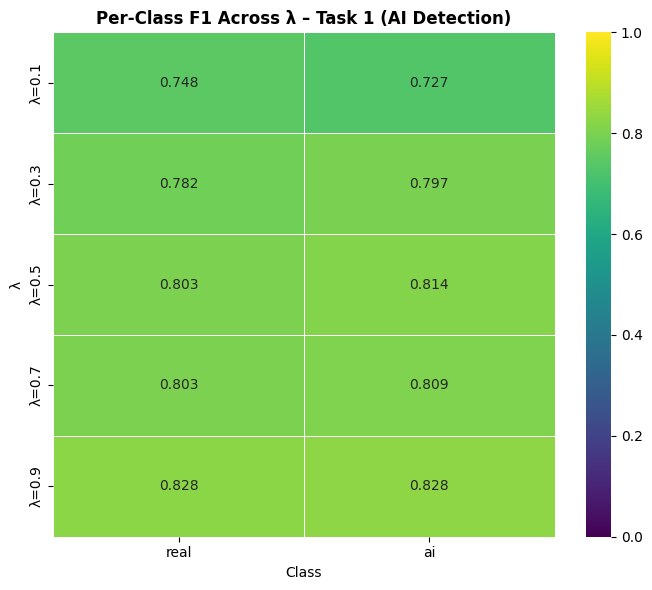

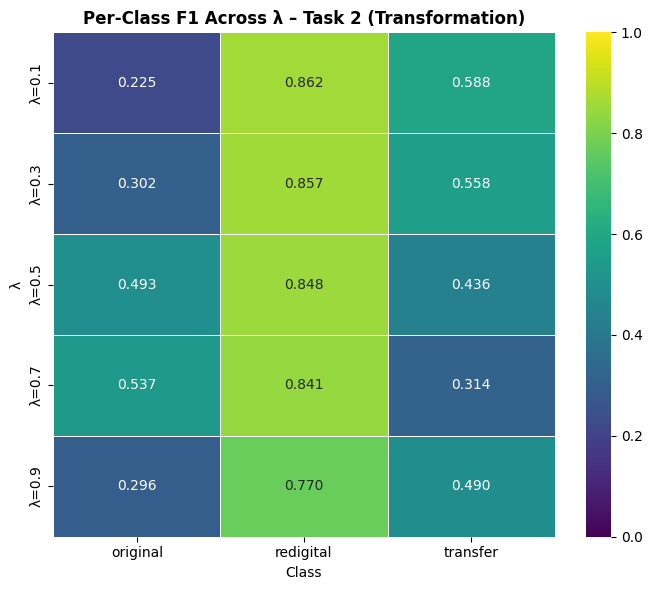

In [32]:
def plot_per_class_f1_across_lambda(test_predictions, lambda_values, class_names, label_key, title):
    """Heatmap: rows = lambda, cols = class, values = F1-score on the test set."""
    f1_matrix = np.zeros((len(lambda_values), len(class_names)))

    for i, lam in enumerate(lambda_values):
        preds = test_predictions[lam]
        y_true = preds[f'true_{label_key}']
        y_pred = preds[f'pred_{label_key}']
        _, _, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, labels=list(range(len(class_names))), average=None
        )
        f1_matrix[i, :] = f1

    fig, ax = plt.subplots(figsize=(7, 4 + 0.4 * len(lambda_values)))
    sns.heatmap(f1_matrix, annot=True, fmt='.3f', cmap='viridis',
                xticklabels=class_names,
                yticklabels=[f'λ={lam}' for lam in lambda_values],
                vmin=0, vmax=1, ax=ax, linewidths=.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Class')
    ax.set_ylabel('λ')
    plt.tight_layout()
    plt.show()

    return f1_matrix


_ = plot_per_class_f1_across_lambda(test_predictions, LAMBDA_VALUES, AI_LABELS,
                                     'ai', 'Per-Class F1 Across λ – Task 1 (AI Detection)')
_ = plot_per_class_f1_across_lambda(test_predictions, LAMBDA_VALUES, DOMAIN_LABELS,
                                     'domain', 'Per-Class F1 Across λ – Task 2 (Transformation)')


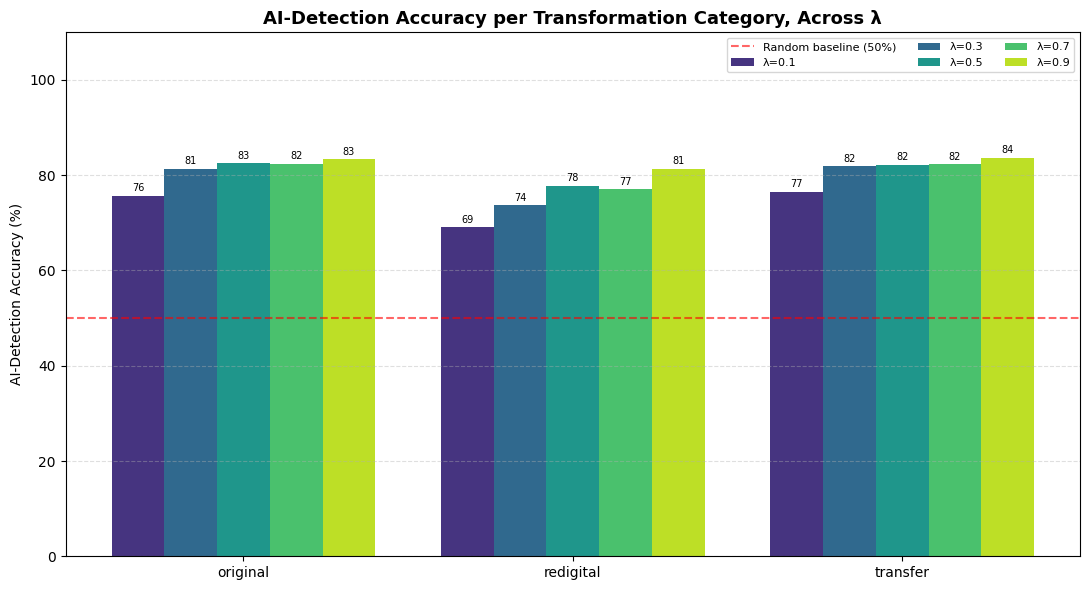

In [33]:
def plot_domain_breakdown_across_lambda(per_domain_accuracy, lambda_values, domain_names):
    """Grouped bar chart: for each transformation category, AI-detection
    accuracy across all lambda values, side by side."""
    x     = np.arange(len(domain_names))
    width = 0.8 / len(lambda_values)
    colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(lambda_values)))

    fig, ax = plt.subplots(figsize=(11, 6))
    for i, lam in enumerate(lambda_values):
        accs = [per_domain_accuracy[lam][d] * 100 for d in domain_names]
        offset = (i - (len(lambda_values) - 1) / 2) * width
        bars = ax.bar(x + offset, accs, width, label=f'λ={lam}', color=colors[i])
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
                    f'{h:.0f}', ha='center', va='bottom', fontsize=7)

    ax.axhline(y=50, color='red', linestyle='--', alpha=0.6, label='Random baseline (50%)')
    ax.set_xticks(x)
    ax.set_xticklabels(domain_names)
    ax.set_ylim(0, 110)
    ax.set_ylabel('AI-Detection Accuracy (%)')
    ax.set_title('AI-Detection Accuracy per Transformation Category, Across λ',
                 fontsize=13, fontweight='bold')
    ax.legend(ncol=3, fontsize=8)
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()


plot_domain_breakdown_across_lambda(per_domain_accuracy, LAMBDA_VALUES, DOMAIN_LABELS)


### Full Numeric Summary Table

A single consolidated table with overall accuracy, macro-F1 for both tasks,
and per-domain AI-detection accuracy, for every lambda — the final reference
table for the report/presentation.

In [34]:
def build_full_summary_table(test_predictions, per_domain_accuracy, lambda_values,
                              ai_labels, domain_labels):
    rows = []
    for lam in lambda_values:
        preds = test_predictions[lam]

        acc_ai     = accuracy_score(preds['true_ai'],     preds['pred_ai'])
        acc_domain = accuracy_score(preds['true_domain'], preds['pred_domain'])

        _, _, f1_ai, _ = precision_recall_fscore_support(
            preds['true_ai'], preds['pred_ai'], labels=list(range(len(ai_labels))), average=None)
        _, _, f1_domain, _ = precision_recall_fscore_support(
            preds['true_domain'], preds['pred_domain'], labels=list(range(len(domain_labels))), average=None)

        row = {
            'lambda': lam,
            'test_acc_ai': acc_ai,
            'test_acc_domain': acc_domain,
            'macro_f1_ai': f1_ai.mean(),
            'macro_f1_domain': f1_domain.mean(),
        }
        for d_name in domain_labels:
            row[f'acc_ai_on_{d_name}'] = per_domain_accuracy[lam][d_name]
        rows.append(row)
    return rows


full_summary = build_full_summary_table(
    test_predictions, per_domain_accuracy, LAMBDA_VALUES, AI_LABELS, DOMAIN_LABELS
)

header = list(full_summary[0].keys())
col_w  = 14
print(' | '.join(f'{h:>{col_w}}' for h in header))
print('-' * (len(header) * (col_w + 3)))
for row in full_summary:
    vals = []
    for h in header:
        v = row[h]
        vals.append(f'{v:>{col_w}.4f}' if isinstance(v, float) else f'{v:>{col_w}}')
    print(' | '.join(vals))


        lambda |    test_acc_ai | test_acc_domain |    macro_f1_ai | macro_f1_domain | acc_ai_on_original | acc_ai_on_redigital | acc_ai_on_transfer
----------------------------------------------------------------------------------------------------------------------------------------
        0.1000 |         0.7378 |         0.5996 |         0.7373 |         0.5583 |         0.7573 |         0.6906 |         0.7657
        0.3000 |         0.7898 |         0.5942 |         0.7895 |         0.5723 |         0.8133 |         0.7371 |         0.8193
        0.5000 |         0.8084 |         0.5978 |         0.8083 |         0.5924 |         0.8253 |         0.7782 |         0.8220
        0.7000 |         0.8058 |         0.5782 |         0.8057 |         0.5637 |         0.8240 |         0.7703 |         0.8233
        0.9000 |         0.8280 |         0.5471 |         0.8280 |         0.5185 |         0.8333 |         0.8141 |         0.8367


## Unimodal Baselines vs Multi-Task

The project specification asks to compare the joint model against **unimodal
baselines** (i.e., models trained on only Task 1 *or* Task 2, corresponding to
$\lambda=1.0$ and $\lambda=0.0$ respectively). These are trained the same way
as every other point on the grid: a fresh model, trained end-to-end, with a
fixed weighting for its entire schedule — here the degenerate cases where one
task's loss has zero weight.

In [35]:
class UnimodalNetAI(nn.Module):
    """Backbone + AI head only (trained with loss_ai, weight_task=1.0)."""
    def __init__(self):
        super().__init__()
        self.backbone    = BackBone()
        self.binary_head = BinaryClassifier()

    def forward(self, x):
        emb = self.backbone(x)
        return self.binary_head(emb), torch.zeros(x.size(0), 3).to(x.device)  # dummy domain logits


class UnimodalNetDomain(nn.Module):
    """Backbone + Domain head only (trained with loss_domain, weight_task=0.0)."""
    def __init__(self):
        super().__init__()
        self.backbone        = BackBone()
        self.transform_head  = TransformClassifier()

    def forward(self, x):
        emb = self.backbone(x)
        return torch.zeros(x.size(0), 2).to(x.device), self.transform_head(emb)  # dummy ai logits


print('Training Unimodal baseline – Task 1 (AI detection only, λ=1.0) ...')
unimodal_ai = UnimodalNetAI()
train_multitask_model(unimodal_ai, train_loader, val_loader,
                      epochs=15, weight_task=1.0, device=DEVICE,
                      checkpoint_path=str(CHECKPOINT_DIR / 'unimodal_ai.pth'))

print('\nTraining Unimodal baseline – Task 2 (Domain only, λ=0.0) ...')
unimodal_domain = UnimodalNetDomain()
train_multitask_model(unimodal_domain, train_loader, val_loader,
                      epochs=15, weight_task=0.0, device=DEVICE,
                      checkpoint_path=str(CHECKPOINT_DIR / 'unimodal_domain.pth'))


Training Unimodal baseline – Task 1 (AI detection only, λ=1.0) ...


[λ=1.0] Epoch [1/15] - Train: 100%|██████████| 105/105 [02:17<00:00,  1.31s/it, loss=0.624]


--- [λ=1.0] Epoch 1 ---
Training Loss:   0.6443
Validation Loss: 0.6064
Val Accuracy AI: 66.58% | Val Accuracy Domain: 33.02%



[λ=1.0] Epoch [2/15] - Train:  95%|█████████▌| 100/105 [02:08<00:06,  1.29s/it, loss=0.518]


KeyboardInterrupt: 

In [ ]:
print('Loading Unimodal baseline – Task 1 (AI detection only, λ=1.0) ...')
unimodal_ai = UnimodalNetAI()
unimodal_ai.load_state_dict(torch.load(CHECKPOINT_DIR / 'unimodal_ai.pth', map_location=DEVICE))
unimodal_ai.to(DEVICE)
unimodal_ai.eval()

print('\nLoading Unimodal baseline – Task 2 (Domain only, λ=0.0) ...')
unimodal_domain = UnimodalNetDomain()
unimodal_domain.load_state_dict(torch.load(CHECKPOINT_DIR / 'unimodal_domain.pth', map_location=DEVICE))
unimodal_domain.to(DEVICE)
unimodal_domain.eval()

print("\nUnimodal baselines loaded successfully!")

In [ ]:
preds_uni_ai     = collect_predictions(unimodal_ai,     test_loader, device=DEVICE)
preds_uni_domain = collect_predictions(unimodal_domain, test_loader, device=DEVICE)

def compare_baselines_all_lambda(test_predictions, lambda_values, preds_uni_ai, preds_uni_domain):
    scenarios = {
        'Unimodal\n(AI only)':     {'ai': preds_uni_ai['pred_ai'],     'domain': preds_uni_ai['pred_domain']},
        'Unimodal\n(Domain only)': {'ai': preds_uni_domain['pred_ai'], 'domain': preds_uni_domain['pred_domain']},
    }
    for lam in lambda_values:
        preds = test_predictions[lam]
        scenarios[f'Multi-Task\n(λ={lam})'] = {'ai': preds['pred_ai'], 'domain': preds['pred_domain']}

    # True labels are the same regardless of model (same test set / same split)
    true_ai     = test_predictions[lambda_values[0]]['true_ai']
    true_domain = test_predictions[lambda_values[0]]['true_domain']

    model_names, accs_ai, accs_domain = [], [], []
    for name, preds in scenarios.items():
        model_names.append(name)
        accs_ai.append(accuracy_score(true_ai,     preds['ai'])     * 100)
        accs_domain.append(accuracy_score(true_domain, preds['domain']) * 100)

    x     = np.arange(len(model_names))
    width = 0.35
    fig, ax = plt.subplots(figsize=(14, 6))
    b1 = ax.bar(x - width/2, accs_ai,     width, label='Task 1 – AI Detection',   color='steelblue')
    b2 = ax.bar(x + width/2, accs_domain, width, label='Task 2 – Transformation', color='darkorange')
    for bars in [b1, b2]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.3,
                    f'{h:.1f}%', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, fontsize=9)
    ax.set_ylim(0, 115)
    ax.set_ylabel('Test Accuracy (%)')
    ax.set_title('Unimodal Baselines vs Multi-Task (All λ) – Test Accuracy', fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

compare_baselines_all_lambda(test_predictions, LAMBDA_VALUES, preds_uni_ai, preds_uni_domain)


## Conclusions

* Five **fully independent** `MultiTaskNet` models were trained, one per
  $\lambda \in \{0.1, 0.3, 0.5, 0.7, 0.9\}$, each from its own random
  initialization and through its own complete training schedule with early
  stopping — never by switching $\lambda$ mid-training.
* Every model was evaluated on the **same** held-out test set with the full
  evaluation suite (confusion matrices, classification reports, ROC/AUC,
  per-class precision/recall/F1, and accuracy broken down by post-processing
  category).
* The aggregate comparison section turns those five independent evaluations
  into a single trade-off view (line/bar charts, F1 heatmaps, per-domain
  breakdown, and a consolidated summary table), without any further training.
* Two degenerate unimodal baselines ($\lambda=1.0$ and $\lambda=0.0$) frame
  the multi-task models at the extremes of the trade-off.
